In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import trace_st as tst  # noqa: E402

In [3]:
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D

import copy

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import cartopy.crs as ccrs
import cartopy.feature as cfeature


In [4]:
def load_json(path):
    path = Path(path)
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def load_jsonl(path):
    path = Path(path)
    if not path.exists():
        return []
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for i, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except Exception:
                print(f"Warning: could not parse line {i} in {path}")
    return rows


def safe_read_csv(path):
    path = Path(path)
    if path.exists():
        return pd.read_csv(path)
    return pd.DataFrame()


def summarize_table(name, df):
    print(f"{name}: shape={df.shape}")
    if len(df) > 0:
        print(f"  columns={list(df.columns[:12])}" + (" ..." if len(df.columns) > 12 else ""))

In [5]:
def run_one_track(full_data, params, date_end):
    out = tst.trajectory.run_track(
        full_data,
        params,
        date_end=date_end,
        return_debug=True,
        return_cluster_summaries=False,
    )
    centers = np.asarray(out["centers"], dtype=float)
    parents = np.asarray(out["parents"], dtype=int)
    return centers, parents, out


In [6]:
def infer_lat_lon_names(da):
    lat_name = "lat" if "lat" in da.coords else "latitude"
    lon_name = "lon" if "lon" in da.coords else "longitude"
    return lat_name, lon_name


def lon0360_to_m180_180(lon):
    lon = np.asarray(lon, dtype=float) % 360.0
    return ((lon + 180.0) % 360.0) - 180.0


def density_for_plotting_m180_180(dens_da):
    lon_name = "lon" if "lon" in dens_da.coords else "longitude"
    return dens_da.assign_coords(
        {lon_name: (((dens_da[lon_name] + 180) % 360) - 180)}
    ).sortby(lon_name)


In [7]:
def compute_density_for_var(full_data_run, ensemble_results, box_size_deg, var_name, normalize=False):
    return compute_trajectory_box_density(
        ensemble_results=ensemble_results,
        full_data_run=full_data_run,
        box_size_deg=box_size_deg,
        selected_var=var_name,
        normalize=normalize,
        skip_step0=True,
    )

def _box_mask_for_center(lat_vals, lon_vals0360, center_lat, center_lon0360, box_size_deg):
    """
    Return boolean mask [lat, lon] for a lat-lon aligned box centered at
    (center_lat, center_lon0360). Handles dateline wrap in 0..360 coordinates.
    """
    if np.isscalar(box_size_deg):
        dlat = dlon = float(box_size_deg)
    else:
        dlat, dlon = map(float, box_size_deg)

    half_lat = dlat / 2.0
    half_lon = dlon / 2.0

    lat_min = center_lat - half_lat
    lat_max = center_lat + half_lat

    lon_min = (center_lon0360 - half_lon) % 360.0
    lon_max = (center_lon0360 + half_lon) % 360.0

    lat_mask = (lat_vals >= lat_min) & (lat_vals <= lat_max)

    if lon_min <= lon_max:
        lon_mask = (lon_vals0360 >= lon_min) & (lon_vals0360 <= lon_max)
    else:
        lon_mask = (lon_vals0360 >= lon_min) | (lon_vals0360 <= lon_max)

    return lat_mask[:, None] & lon_mask[None, :]


def compute_trajectory_box_density(
    ensemble_results,
    full_data_run,
    box_size_deg,
    selected_var=None,
    normalize=False,
    skip_step0=True,
):
    """
    Compute density = number of times an ensemble box footprint passes over each grid cell.
    """
    lat_name, lon_name = infer_lat_lon_names(full_data_run)
    lat_vals = np.asarray(full_data_run[lat_name].values, dtype=float)
    lon_vals = np.asarray(full_data_run[lon_name].values, dtype=float) % 360.0

    dens = np.zeros((len(lat_vals), len(lon_vals)), dtype=np.float64)

    var_names = list(full_data_run["var"].values) if "var" in full_data_run.coords else None
    selected_parent_index = None

    if isinstance(selected_var, str):
        if var_names is None:
            raise ValueError("selected_var given as string, but full_data_run has no 'var' coord.")
        if selected_var not in var_names:
            raise ValueError(f"selected_var='{selected_var}' not found in var names: {var_names}")
        selected_parent_index = var_names.index(selected_var) + 1
    elif isinstance(selected_var, (int, np.integer)):
        selected_parent_index = int(selected_var)
    elif selected_var is not None:
        raise ValueError("selected_var must be None, int, or str.")

    start_idx = 1 if skip_step0 else 0

    for res in ensemble_results:
        centers = np.asarray(res["centers"], dtype=float)
        parents = np.asarray(res["parents"], dtype=int)

        for i in range(start_idx, len(centers)):
            if selected_parent_index is not None and parents[i] != selected_parent_index:
                continue

            c_lat = float(centers[i, 0])
            c_lon0360 = float(centers[i, 1]) % 360.0

            mask = _box_mask_for_center(
                lat_vals=lat_vals,
                lon_vals0360=lon_vals,
                center_lat=c_lat,
                center_lon0360=c_lon0360,
                box_size_deg=box_size_deg,
            )
            dens += mask.astype(np.float64)

    if normalize and np.nanmax(dens) > 0:
        dens = dens / np.nanmax(dens)

    dens_da = xr.DataArray(
        dens,
        coords={lat_name: full_data_run[lat_name], lon_name: full_data_run[lon_name]},
        dims=(lat_name, lon_name),
        name="trajectory_box_density",
    )
    return dens_da


def choose_contour_steps(n_steps, every=2):
    """
    Choose step indices for contours. Always include first and last.
    """
    idx = list(range(0, n_steps, every))
    if (n_steps - 1) not in idx:
        idx.append(n_steps - 1)
    return np.array(sorted(set(idx)), dtype=int)


def get_field_at_track_step(full_data_run, var_name, date_end, step_idx):
    """
    Returns the 2D field for `var_name` at the trajectory time corresponding
    to `step_idx` days before `date_end`.
    """
    target_time = pd.Timestamp(date_end) - pd.Timedelta(days=int(step_idx))
    da = full_data_run.sel(var=var_name).sel(time=target_time, method="nearest")
    return da

In [8]:


# =========================================================
# Small helpers
# =========================================================

def _accumulate_density_box(density, xs, ys, centers, box_size):
    centers = np.asarray(centers, dtype=float)
    if len(centers) == 0:
        return density

    half = float(box_size) / 2.0
    for yc, xc in centers:
        x0 = xc - half
        x1 = xc + half
        y0 = yc - half
        y1 = yc + half

        xmask = (xs >= x0) & (xs <= x1)
        ymask = (ys >= y0) & (ys <= y1)

        if np.any(xmask) and np.any(ymask):
            density[np.ix_(ymask, xmask)] += 1.0
    return density

def load_bundle_for_trial(trial_id, jobs_df):
    row = jobs_df.loc[jobs_df["trial_id"] == trial_id]
    if len(row) == 0:
        raise ValueError(f"trial_id={trial_id} not found in jobs_df")
    row = row.iloc[0]

    npz_path = Path(row["bundle_npz"])
    json_path = Path(row["bundle_json"])

    if not npz_path.exists():
        raise FileNotFoundError(npz_path)
    if not json_path.exists():
        raise FileNotFoundError(json_path)

    bundle_npz = np.load(npz_path, allow_pickle=True)
    with open(json_path, "r", encoding="utf-8") as f:
        bundle_meta = json.load(f)

    return row, bundle_npz, bundle_meta


def reconstruct_ensemble_from_bundle(bundle_npz):
    centers_pad = bundle_npz["centers"]
    parents_pad = bundle_npz["parents"]
    lengths = bundle_npz["lengths"]
    ok_arr = bundle_npz["ok"]
    member_ids = bundle_npz["member_id"]

    ensemble_results = []
    for i in range(len(lengths)):
        L = int(lengths[i])
        if int(ok_arr[i]) != 1 or L <= 0:
            continue
        ensemble_results.append({
            "member_id": int(member_ids[i]),
            "centers": np.asarray(centers_pad[i, :L, :], dtype=float),
            "parents": np.asarray(parents_pad[i, :L], dtype=int),
        })
    return ensemble_results


def compute_density_for_var_multi(
    full_data_run,
    ensemble_results,
    box_size_deg,
    var_name,
):
    lat_name, lon_name = infer_lat_lon_names(full_data_run)
    ys = np.asarray(full_data_run[lat_name].values, dtype=float)
    xs = np.asarray(full_data_run[lon_name].values, dtype=float)

    var_names = list(full_data_run["var"].values)
    var_to_parent = {v: i + 1 for i, v in enumerate(var_names)}
    parent_id = var_to_parent[var_name]

    density = np.zeros((len(ys), len(xs)), dtype=float)

    for res in ensemble_results:
        centers = np.asarray(res["centers"], dtype=float)
        parents = np.asarray(res["parents"], dtype=int)
        if len(centers) == 0 or len(parents) == 0:
            continue

        mask = parents == parent_id
        if np.any(mask):
            density = _accumulate_density_box(
                density,
                xs,
                ys,
                centers[mask],
                box_size_deg,
            )

    dens_da = xr.DataArray(
        density,
        dims=(lat_name, lon_name),
        coords={lat_name: ys, lon_name: xs},
        name=f"density_{var_name}",
    )
    return dens_da

def plot_trace_st_debby_6panel_multi_trials(
    trial_ids,
    jobs_df,
    members_df,
    full_data_run,
    *,
    date_end,
    run_one_track,
    panel_vars=("Tb", "vo", "precip"),
    panel_titles=None,
    contour_every=48,
    contour_level_std=100,
    contour_mode=None,
    timeres_hours=1.0,
    extent=(-50, 40, 0, 40),
    density_cmap="hot_r",
    track_cmap="cool_r",
    density_alpha=0.90,
    contour_linewidth=1.0,
    track_linewidth=1.0,
    point_size=18,
    scatter_stride=12,
    ensemble_linewidth=0.55,
    ensemble_alpha=0.10,
    ensemble_markersize=7,
    density_percentile_cap=100.0,
    event_lon=None,
    event_lat=None,
    storm_lon=None,
    storm_lat=None,
    storm_hours_back=None,
    storm_marker="X",
    storm_marker_size=55,
    storm_stride=2,
    distance_metric_col="track_dist_km_mean",
    density_boxplot_cols=("density_full::Tb", "density_full::vo", "density_full::precip"),
    random_members_per_trial=None,
    random_seed=11,
):
    trial_ids = list(trial_ids)
    if len(trial_ids) == 0:
        raise ValueError("trial_ids is empty")

    if panel_titles is None:
        panel_titles = {
            "Tb": "Brightness temperature",
            "vo": "Mid-level vorticity",
            "precip": "Precipitation",
        }

    if contour_mode is None:
        contour_mode = {
            "Tb": "both",
            "vo": "positive",
            "precip": "positive",
        }
    
    rng = np.random.default_rng(random_seed)

    lat_name, lon_name = infer_lat_lon_names(full_data_run)
    var_names = list(full_data_run["var"].values)

    marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*"]
    marker_map = {name: marker_cycle[i % len(marker_cycle)] for i, name in enumerate(var_names)}

    # -------------------------------------------------
    # Collect all ensembles + deterministic runs
    # -------------------------------------------------
    all_ensemble_results = []
    deterministic_runs = []
    box_sizes = []

    for tid in trial_ids:
        row, bundle_npz, bundle_meta = load_bundle_for_trial(tid, jobs_df)

        params_trial = copy.deepcopy(bundle_meta["params"])
        box_sizes.append(float(params_trial["box_size"]))

        ens_trial = reconstruct_ensemble_from_bundle(bundle_npz)
        all_ensemble_results.extend(ens_trial)

    if len(all_ensemble_results) == 0:
        raise ValueError("No valid ensemble members found in selected trials")

    box_size_plot = float(np.median(box_sizes))
    
    # -------------------------------------------------
    # Optional random subsample for panel A only
    # -------------------------------------------------
    ensemble_results_panelA = []

    if random_members_per_trial is None:
        ensemble_results_panelA = all_ensemble_results
    else:
        for tid in trial_ids:
            row, bundle_npz, bundle_meta = load_bundle_for_trial(tid, jobs_df)
            ens_trial = reconstruct_ensemble_from_bundle(bundle_npz)

            if len(ens_trial) <= random_members_per_trial:
                ensemble_results_panelA.extend(ens_trial)
            else:
                idx_keep = rng.choice(
                    np.arange(len(ens_trial)),
                    size=random_members_per_trial,
                    replace=False,
                )
                idx_keep = np.sort(idx_keep)
                ensemble_results_panelA.extend([ens_trial[i] for i in idx_keep])

    # -------------------------------------------------
    # Density fields for B/C/D
    # -------------------------------------------------
    dens_plot_list = []
    vmax_candidates = []
    
    all_ensemble_results_density = drop_initial_steps_from_ensemble(
        all_ensemble_results,
        n_skip=1,
    )
    
    for v in panel_vars:
        dens = compute_density_for_var_multi(
            full_data_run=full_data_run,
            ensemble_results=all_ensemble_results_density,
            box_size_deg=box_size_plot,
            var_name=v,
        )
        dens_plot = density_for_plotting_m180_180(dens)
        dens_plot_list.append(dens_plot)

        vals = np.asarray(dens_plot.values, dtype=float)
        vals = vals[np.isfinite(vals)]
        if vals.size:
            vmax_candidates.append(np.percentile(vals, density_percentile_cap))

    density_vmax = max(vmax_candidates) if len(vmax_candidates) else 1.0
    density_vmin = 0.0

    # -------------------------------------------------
    # Lag colormap
    # -------------------------------------------------
    max_steps = max(len(r["centers"]) for r in all_ensemble_results)
    hours_back_ref = np.arange(max_steps) * float(timeres_hours)

    lag_cmap = plt.get_cmap(track_cmap)
    lag_norm = mpl.colors.Normalize(
        vmin=float(np.nanmin(hours_back_ref)),
        vmax=float(np.nanmax(hours_back_ref)),
    )

    # -------------------------------------------------
    # Panel E data: per-trial density integrals
    # -------------------------------------------------
    jobs_sel = jobs_df[jobs_df["trial_id"].isin(trial_ids)].copy()

    boxplot_data = []
    boxplot_labels = []
    for col in density_boxplot_cols:
        if col in jobs_sel.columns:
            vals = pd.to_numeric(jobs_sel[col], errors="coerce").dropna().values
            if len(vals):
                boxplot_data.append(vals)
                boxplot_labels.append(col.split("::")[-1])

    # -------------------------------------------------
    # Panel F data: all member distances
    # -------------------------------------------------
    members_sel = members_df[members_df["trial_id"].isin(trial_ids)].copy()
    dist_vals = np.array([], dtype=float)
    if distance_metric_col in members_sel.columns:
        dist_vals = pd.to_numeric(members_sel[distance_metric_col], errors="coerce")
        dist_vals = dist_vals[np.isfinite(dist_vals)].values

    # -------------------------------------------------
    # Figure
    # -------------------------------------------------
    proj = ccrs.PlateCarree()
    # -------------------------------------------------
    # Figure
    # -------------------------------------------------
    fig = plt.figure(figsize=(18, 10), constrained_layout=False)

    axA = fig.add_subplot(2, 3, 1, projection=proj)
    axB = fig.add_subplot(2, 3, 2, projection=proj)
    axC = fig.add_subplot(2, 3, 3, projection=proj)
    axD = fig.add_subplot(2, 3, 4, projection=proj)
    axE = fig.add_subplot(2, 3, 5)
    axF = fig.add_subplot(2, 3, 6)

    map_axes = [axA, axB, axC, axD]
    panel_letters = ["A", "B", "C", "D", "E", "F"]

    # -------------------------------------------------
    # Common map styling
    # -------------------------------------------------
    for ax in map_axes:
        ax.set_extent(extent, crs=proj)
        ax.set_facecolor("white")
        ax.add_feature(cfeature.LAND, facecolor="white", edgecolor="none", zorder=0)
        ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4, zorder=3)
        gl = ax.gridlines(draw_labels=False, linewidth=0.35, alpha=0.35, linestyle="--")
        gl.top_labels = False
        gl.right_labels = False

    # =================================================
    # A. All trajectories across all selected trials
    # =================================================
    for res in ensemble_results_panelA:
        centers_ens = np.asarray(res["centers"], dtype=float)
        parents_ens = np.asarray(res["parents"], dtype=int)

        lats_ens = centers_ens[:, 0]
        lons_ens = lon0360_to_m180_180(centers_ens[:, 1] % 360.0)

        steps_ens = np.arange(len(lats_ens))
        hours_back_ens = steps_ens * float(timeres_hours)

        axA.plot(
            lons_ens,
            lats_ens,
            "-",
            color="k",
            linewidth=ensemble_linewidth,
            alpha=ensemble_alpha,
            transform=proj,
            zorder=2,
        )

        p0_ens = np.clip(parents_ens - 1, 0, len(var_names) - 1)
        parent_labels_ens = np.array([var_names[i] for i in p0_ens])

        for vname in var_names:
            mask = parent_labels_ens == vname
            if not np.any(mask):
                continue

            idx = np.where(mask)[0][::scatter_stride]
            axA.scatter(
                lons_ens[idx],
                lats_ens[idx],
                c=hours_back_ens[idx],
                cmap=lag_cmap,
                norm=lag_norm,
                marker=marker_map[vname],
                s=ensemble_markersize,
                alpha=0.50,
                edgecolor="none",
                transform=proj,
                zorder=3,
            )

    if storm_lon is not None and storm_lat is not None and storm_hours_back is not None:
        idx_storm = np.arange(len(storm_lon))[::storm_stride]
        axA.scatter(
            np.asarray(storm_lon)[idx_storm],
            np.asarray(storm_lat)[idx_storm],
            c=np.asarray(storm_hours_back)[idx_storm],
            cmap=lag_cmap,
            norm=lag_norm,
            marker=storm_marker,
            s=storm_marker_size,
            edgecolor="k",
            linewidth=0.4,
            transform=proj,
            zorder=6,
        )

    axA.set_title(
        f"{panel_letters[0]}. Trajectories across trials",
        loc="left",
        fontsize=14,
        fontweight="bold",
    )

    # =================================================
    # B/C/D. Aggregated densities across all selected trials
    # =================================================
    density_mappable = None
    
    time_values = pd.to_datetime(full_data_run.time.values)
    date_end_ts = pd.Timestamp(date_end)
    
    hours_back_available = (date_end_ts - time_values) / pd.Timedelta(hours=1)
    hours_back_available = np.asarray(hours_back_available, dtype=float)
    
    valid_back = hours_back_available >= 0
    max_back_hours = float(np.nanmax(hours_back_available[valid_back])) if np.any(valid_back) else 0.0
    
    max_step_from_data = int(np.floor(max_back_hours / timeres_hours))
    contour_steps = choose_contour_steps(max_step_from_data + 1, contour_every)

    for ax, vname, dens_plot, letter in zip([axB, axC, axD], panel_vars, dens_plot_list, panel_letters[1:4]):
        lonp = np.asarray(dens_plot[lon_name].values, dtype=float)
        latp = np.asarray(dens_plot[lat_name].values, dtype=float)
        densv = np.asarray(dens_plot.values, dtype=float)

        mesh = ax.pcolormesh(
            lonp,
            latp,
            densv,
            transform=proj,
            shading="auto",
            cmap=density_cmap,
            vmin=density_vmin,
            vmax=density_vmax,
            alpha=density_alpha,
            zorder=1,
            rasterized=True,
        )
        density_mappable = mesh

        # contours from full_data
        this_mode = contour_mode.get(vname, "positive") if isinstance(contour_mode, dict) else contour_mode

        for step_idx in contour_steps:
            target_time = pd.Timestamp(date_end) - pd.Timedelta(hours=int(step_idx * timeres_hours))
            da2d = full_data_run.sel(var=vname).sel(time=target_time, method="nearest")

            da2d_plot = da2d.assign_coords(
                {lon_name: (((da2d[lon_name] + 180) % 360) - 180)}
            ).sortby(lon_name)

            lons_c = np.asarray(da2d_plot[lon_name].values, dtype=float)
            lats_c = np.asarray(da2d_plot[lat_name].values, dtype=float)
            vals_c = np.asarray(da2d_plot.values, dtype=float)

            contour_color = lag_cmap(lag_norm(step_idx * timeres_hours))

            if this_mode == "positive":
                levels = [contour_level_std]
            elif this_mode == "negative":
                levels = [-contour_level_std]
            elif this_mode == "both":
                levels = [-contour_level_std, contour_level_std]
            else:
                raise ValueError("contour_mode must be 'positive', 'negative', 'both', or dict")

            try:
                ax.contour(
                    lons_c,
                    lats_c,
                    vals_c,
                    levels=levels,
                    colors=[contour_color] * len(levels),
                    linewidths=contour_linewidth,
                    alpha=0.90,
                    transform=proj,
                    zorder=4,
                )
            except Exception:
                pass

        if storm_lon is not None and storm_lat is not None and storm_hours_back is not None:
            idx_storm = np.arange(len(storm_lon))[::storm_stride]
            ax.scatter(
                np.asarray(storm_lon)[idx_storm],
                np.asarray(storm_lat)[idx_storm],
                c=np.asarray(storm_hours_back)[idx_storm],
                cmap=lag_cmap,
                norm=lag_norm,
                marker=storm_marker,
                s=storm_marker_size,
                edgecolor="k",
                linewidth=0.4,
                zorder=7,
                transform=proj,
            )

        ax.set_title(
            f"{letter}. {panel_titles.get(vname, vname)}",
            loc="left",
            fontsize=14,
            fontweight="bold",
        )

    # =================================================
    # E. Boxplots of integrated densities across selected trials
    # =================================================
    if len(boxplot_data):
        bp = axE.boxplot(
            boxplot_data,
            labels=boxplot_labels,
            patch_artist=True,
            widths=0.6,
            showfliers=True,
        )
        for patch in bp["boxes"]:
            patch.set_alpha(0.6)
        axE.set_ylabel("Integrated density")
    else:
        axE.text(0.5, 0.5, "No density columns found", ha="center", va="center")
    axE.set_title(
        f"{panel_letters[4]}. Per-trial density distributions",
        loc="left",
        fontsize=14,
        fontweight="bold",
    )

    # =================================================
    # F. Histogram of member distances from actual track
    # =================================================
    if len(dist_vals):
        axF.hist(dist_vals, bins=25, alpha=0.75)
        axF.axvline(np.nanmedian(dist_vals), linestyle="--", linewidth=1.2, label=f"median = {np.nanmedian(dist_vals):.1f} km")
        axF.set_xlabel("Member mean distance from observed track (km)")
        axF.set_ylabel("Count")
        axF.legend()
    else:
        axF.text(0.5, 0.5, f"No values found for {distance_metric_col}", ha="center", va="center")
    axF.set_title(
        f"{panel_letters[5]}. Distance-to-track distribution",
        loc="left",
        fontsize=14,
        fontweight="bold",
    )

    # -------------------------------------------------
    # Legend + colorbars
    # -------------------------------------------------
    legend_handles = [
        Line2D([0], [0], marker=marker_map[v], linestyle="None",
               markerfacecolor="k", markeredgecolor="k",
               markersize=7, label=v)
        for v in var_names
    ]
    legend_handles += [
        Line2D([0], [0], marker=storm_marker, color="white", markeredgecolor="k",
               linestyle="None", markersize=9, label="Observed track"),
    ]

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.28, 0.01),
        ncol=4,
        frameon=True,
        fontsize=10,
        title="Parent / markers",
        title_fontsize=11,
    )

    fig.subplots_adjust(left=0.04, right=0.97, top=0.93, bottom=0.12, wspace=0.22, hspace=0.25)

    cax_den = fig.add_axes([0.46, 0.055, 0.18, 0.018])
    cb_den = fig.colorbar(density_mappable, cax=cax_den, orientation="horizontal")
    cb_den.set_label("Trajectory density", fontsize=10)

    sm_lag = mpl.cm.ScalarMappable(norm=lag_norm, cmap=lag_cmap)
    sm_lag.set_array([])
    cax_lag = fig.add_axes([0.70, 0.055, 0.18, 0.018])
    cb_lag = fig.colorbar(sm_lag, cax=cax_lag, orientation="horizontal")
    cb_lag.set_label("Hours back from target date", fontsize=10)

    fig.suptitle(
        f"Debby multi-trial summary ({len(trial_ids)} trials, {len(all_ensemble_results)} ensemble members)",
        fontsize=15,
        fontweight="bold",
        y=0.98,
    )

    return fig



In [9]:
def drop_initial_steps_from_ensemble(ensemble_results, n_skip=1):
    trimmed = []
    for res in ensemble_results:
        centers = np.asarray(res["centers"])
        parents = np.asarray(res["parents"])

        if len(centers) <= n_skip or len(parents) <= n_skip:
            continue

        new_res = dict(res)
        new_res["centers"] = centers[n_skip:]
        new_res["parents"] = parents[n_skip:]
        trimmed.append(new_res)

    return trimmed

# Results Debby

In [10]:
OUTDIR = Path("/glade/derecho/scratch/jhayron/DataCaStLeBTs/ResultsDebby/hp_search_v2")
BUNDLES_DIR = OUTDIR / "bundles"

jobs_csv_final = OUTDIR / "results_jobs_final.csv"
alphas_csv_final = OUTDIR / "results_alphas_final.csv"
members_csv_final = OUTDIR / "results_members_final.csv"

jobs_csv_snapshot = OUTDIR / "results_jobs_snapshot.csv"
alphas_csv_snapshot = OUTDIR / "results_alphas_snapshot.csv"
members_csv_snapshot = OUTDIR / "results_members_snapshot.csv"

jobs_jsonl = OUTDIR / "results_jobs.jsonl"
alphas_jsonl = OUTDIR / "results_alphas.jsonl"
members_jsonl = OUTDIR / "results_members.jsonl"

meta_json = OUTDIR / "run_metadata.json"
summary_json = OUTDIR / "run_summary.json"

print("OUTDIR:", OUTDIR)
print("Exists:", OUTDIR.exists())
print("Bundles dir exists:", BUNDLES_DIR.exists())


if jobs_csv_final.exists():
    jobs_df = pd.read_csv(jobs_csv_final)
elif jobs_csv_snapshot.exists():
    jobs_df = pd.read_csv(jobs_csv_snapshot)
else:
    jobs_df = pd.DataFrame(load_jsonl(jobs_jsonl))

if members_csv_final.exists():
    members_df = pd.read_csv(members_csv_final)
elif members_csv_snapshot.exists():
    members_df = pd.read_csv(members_csv_snapshot)
else:
    members_df = pd.DataFrame(load_jsonl(members_jsonl))

meta = load_json(meta_json) if meta_json.exists() else {}
summary = load_json(summary_json) if summary_json.exists() else {}

bundle_npz_files = sorted(BUNDLES_DIR.glob("*.npz")) if BUNDLES_DIR.exists() else []
bundle_json_files = sorted(BUNDLES_DIR.glob("*.json")) if BUNDLES_DIR.exists() else []

summarize_table("jobs_df", jobs_df)
summarize_table("members_df", members_df)

print("n bundle npz files:", len(bundle_npz_files))
print("n bundle json files:", len(bundle_json_files))

if meta:
    print("\nrun_metadata:")
    for k, v in meta.items():
        print(f"  {k}: {v}")

if summary:
    print("\nrun_summary:")
    for k, v in summary.items():
        print(f"  {k}: {v}")

OUTDIR: /glade/derecho/scratch/jhayron/DataCaStLeBTs/ResultsDebby/hp_search_v2
Exists: True
Bundles dir exists: True
jobs_df: shape=(300, 81)
  columns=['case_name', 'trial_id', 'timeres', 'spaceres', 'box_size', 'radius', 'starting_lat', 'starting_lon', 'timewindow', 'child_of_interest', 'n_steps_time', 'averaging_winners'] ...
members_df: shape=(9000, 51)
  columns=['member_id', 'ok', 'error', 'track_dist_km_mean', 'track_dist_km_median', 'track_dist_km_max', 'track_dist_km_final', 'n_valid_track_points', 'n_steps', 'path_length', 'net_displacement', 'mean_step'] ...
n bundle npz files: 300
n bundle json files: 300

run_metadata:
  case_name: debby
  seed: 11
  n_trials: 300
  n_workers: 120
  ensemble_size: 30
  flush_every: 10
  n_total_trials: 300
  n_completed_trials_found_at_start: 0
  n_pending_trials_at_start: 300
  updated_at: 2026-04-05T17:02:40.460974+00:00

run_summary:
  finished_at: 2026-04-05T19:25:25.247680+00:00
  elapsed_sec: 8564.784551627934
  n_trials_total: 300
 

In [11]:
good_jobs = jobs_df[(jobs_df['n_members_failed']<10)&(jobs_df['mean_traj_length']>12*24)]
bad_jobs = jobs_df[(jobs_df['n_members_failed']>10)|(jobs_df['mean_traj_length']<12*24)]

In [12]:
len(good_jobs)/len(jobs_df)

0.22666666666666666

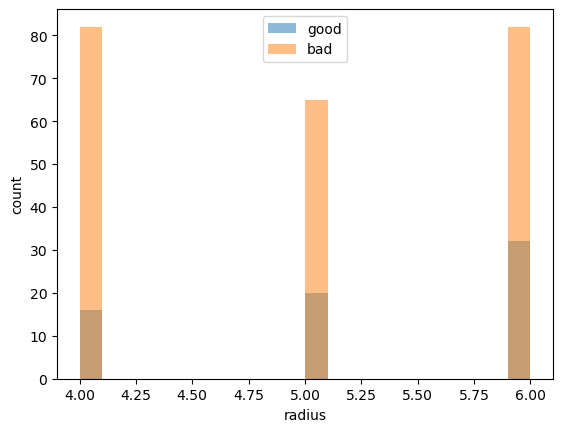

In [13]:
plt.hist(good_jobs.radius, bins=20, alpha=0.5, label="good")
plt.hist(bad_jobs.radius, bins=20, alpha=0.5, label="bad")

plt.legend()
plt.xlabel("radius")
plt.ylabel("count")
plt.show()

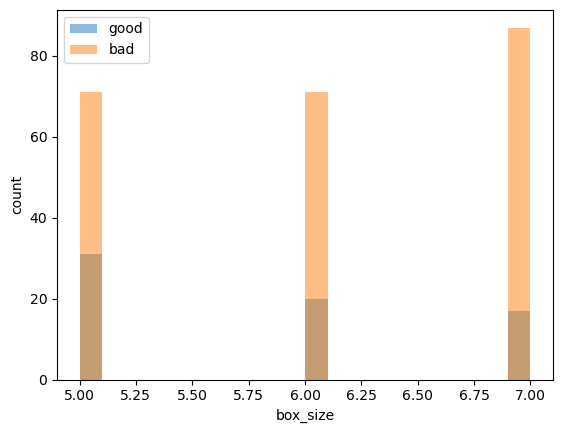

In [14]:
plt.hist(good_jobs.box_size, bins=20, alpha=0.5, label="good")
plt.hist(bad_jobs.box_size, bins=20, alpha=0.5, label="bad")

plt.legend()
plt.xlabel("box_size")
plt.ylabel("count")
plt.show()

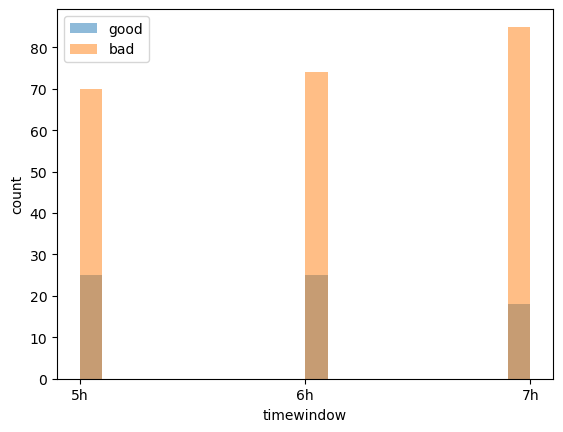

In [15]:
plt.hist(good_jobs.timewindow, bins=20, alpha=0.5, label="good")
plt.hist(bad_jobs.timewindow, bins=20, alpha=0.5, label="bad")

plt.legend()
plt.xlabel("timewindow")
plt.ylabel("count")
plt.show()

(array([ 1.,  5., 18., 11.,  8.,  8.,  3., 10.,  2.,  2.]),
 array([ 418680. ,  730230.8, 1041781.6, 1353332.4, 1664883.2, 1976434. ,
        2287984.8, 2599535.6, 2911086.4, 3222637.2, 3534188. ]),
 <BarContainer object of 10 artists>)

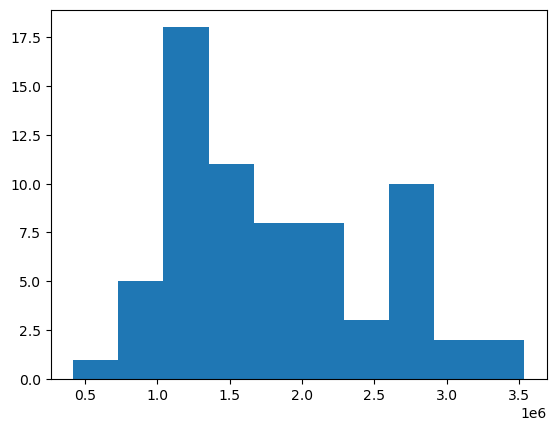

In [16]:
plt.hist(good_jobs['density_range::vo']-good_jobs['density_range::precip'])
# plt.hist()

In [17]:
import json
from pathlib import Path
import copy
import numpy as np
import pandas as pd
import xarray as xr

# ==================================================
# Choose trial
# ==================================================
trial_id_plot = 107   # <--- change this

# ==================================================
# Locate row and bundle
# ==================================================
row = jobs_df.loc[jobs_df["trial_id"] == trial_id_plot]
if len(row) == 0:
    raise ValueError(f"trial_id={trial_id_plot} not found in jobs_df")

row = row.iloc[0]

bundle_npz_path = Path(row["bundle_npz"])
bundle_json_path = Path(row["bundle_json"])

if not bundle_npz_path.exists():
    raise FileNotFoundError(bundle_npz_path)
if not bundle_json_path.exists():
    raise FileNotFoundError(bundle_json_path)

bundle_npz = np.load(bundle_npz_path, allow_pickle=True)
with open(bundle_json_path, "r", encoding="utf-8") as f:
    bundle_meta = json.load(f)

params_trial = copy.deepcopy(bundle_meta["params"])

print("trial_id:", trial_id_plot)
print("bundle:", bundle_npz_path.name)
print("status:", row.get("status", "NA"))
print("mean traj length:", row.get("mean_traj_length", np.nan))
print("mean member mean track dist (km):", row.get("mean_of_member_mean_track_dist_km", np.nan))

# ==================================================
# Rebuild Debby data
# ==================================================
path_files_debby = "/glade/derecho/scratch/jhayron/DataCaStLeBTs/FilesDebby/"

var_tb = xr.open_dataset(f"{path_files_debby}/BT_anomalies_TC_argon.nc4").Tb
var_vo = xr.open_dataset(f"{path_files_debby}/Vo_anomalies_TC_500-700.nc4").vo
var_pr = xr.open_dataset(f"{path_files_debby}/P_anomalies_TC_argon2.nc4").precipitation

datalist = []
for timetemp in var_pr.time:
    hourtemp = pd.to_datetime(timetemp.values).hour
    datatemp = var_pr.sel(time=timetemp, hour=hourtemp)
    datalist.append(datatemp)

var_pr = xr.concat(datalist, dim="time").fillna(0)

var_vo = var_vo.rename({"latitude": "lat", "longitude": "lon"})
var_tb = var_tb.assign_coords(time=var_tb.time.dt.round("1H"))
var_vo = var_vo.assign_coords(time=var_vo.time.dt.round("1H"))
var_pr = var_pr.assign_coords(time=var_pr.time.dt.round("1H"))

full_data_debby = xr.concat(
    [var_tb, var_vo, var_pr],
    dim=xr.IndexVariable("var", ["Tb", "vo", "precip"])
)
full_data_debby = full_data_debby.assign_coords(
    lon=(full_data_debby.lon % 360)
).sortby("lon")

# ==================================================
# Observed Debby track
# ==================================================
date_end_debby = "2006-08-26 00:00:00"
event_lat_debby = 28.0
event_lon_debby = -46.0

ds_tracks = xr.open_dataset("IBTrACS.NA.v04r01.nc")
where_debby = np.where(ds_tracks.sid == b"2006234N12338")[0][0]

time_storm = pd.to_datetime(ds_tracks.time.values[where_debby])
lat_storm = np.asarray(ds_tracks.lat.values[where_debby], dtype=float)
lon_storm = np.asarray(ds_tracks.lon.values[where_debby], dtype=float)

valid = (~pd.isna(time_storm)) & np.isfinite(lat_storm) & np.isfinite(lon_storm)
time_storm = pd.to_datetime(time_storm[valid])
lat_storm = lat_storm[valid]
lon_storm = lon_storm[valid]

lon_storm_plot = ((lon_storm + 180) % 360) - 180

date_end_dt = pd.Timestamp(date_end_debby)
hours_back_storm = (date_end_dt - time_storm) / pd.Timedelta(hours=1)

valid_back = hours_back_storm >= 0
time_storm = time_storm[valid_back]
lat_storm = lat_storm[valid_back]
lon_storm_plot = lon_storm_plot[valid_back]
hours_back_storm = np.asarray(hours_back_storm[valid_back], dtype=float)

# ==================================================
# Reconstruct ensemble from bundle
# ==================================================
centers_pad = bundle_npz["centers"]
parents_pad = bundle_npz["parents"]
lengths = bundle_npz["lengths"]
ok_arr = bundle_npz["ok"]
member_ids = bundle_npz["member_id"]

ensemble_results_trial = []
for i in range(len(lengths)):
    L = int(lengths[i])
    if int(ok_arr[i]) != 1 or L <= 0:
        continue

    ensemble_results_trial.append({
        "member_id": int(member_ids[i]),
        "centers": np.asarray(centers_pad[i, :L, :], dtype=float),
        "parents": np.asarray(parents_pad[i, :L], dtype=int),
    })

print("usable ensemble members:", len(ensemble_results_trial))

# ==================================================
# Deterministic run using this trial's hyperparameters
# ==================================================
params_det = copy.deepcopy(params_trial)
params_det["montecarlo"] = False
params_det["starting_lat"] = event_lat_debby
params_det["starting_lon"] = event_lon_debby

centers_det, parents_det, out_det = run_one_track(
    full_data_debby,
    params_det,
    date_end_debby,
)

trial_id: 107
bundle: debby_trial_00107.npz
status: ok
mean traj length: 308.8333333333333
mean member mean track dist (km): 757.1847807164605
usable ensemble members: 30


In [19]:
# ==================================================
# Plot
# ==================================================
extent_debby = (-50, 40, 0, 40)

panel_vars_debby = ["Tb", "vo", "precip"]
panel_titles_debby = {
    "Tb": "Brightness temperature",
    "vo": "Mid-level vorticity",
    "precip": "Precipitation",
}
contour_mode_debby = {
    "Tb": "both",
    "vo": "positive",
    "precip": "positive",
}


In [20]:
good_jobs

,case_name,trial_id,timeres,spaceres,box_size,radius,starting_lat,starting_lon,timewindow,child_of_interest,...,density_range_end_step_exclusive,density_range::Tb,density_range::vo,density_range::precip,elapsed_sec,status,ok,error,bundle_npz,bundle_json
0,debby,111,1h,0.25,6.0,6,28.0,-46.0,5h,3,...,360,565104.0,3146352.0,437784.0,2614.971661,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
1,debby,76,1h,0.25,6.0,6,28.0,-46.0,5h,3,...,360,399816.0,2364984.0,457344.0,2272.634097,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
2,debby,186,1h,0.25,7.0,6,28.0,-46.0,5h,3,...,360,544488.0,3625244.0,509152.0,3149.357248,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
3,debby,259,1h,0.25,6.0,5,28.0,-46.0,5h,3,...,360,459072.0,2650416.0,376608.0,2070.294749,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
4,debby,118,1h,0.25,6.0,6,28.0,-46.0,6h,3,...,360,642792.0,2694456.0,428856.0,2976.727537,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,debby,10,1h,0.25,5.0,4,28.0,-46.0,6h,3,...,360,434960.0,1311240.0,235840.0,1620.194246,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
125,debby,16,1h,0.25,7.0,5,28.0,-46.0,7h,3,...,360,553168.0,2455348.0,360836.0,4518.359571,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
148,debby,69,1h,0.25,5.0,5,28.0,-46.0,5h,3,...,360,431960.0,1445323.0,253180.0,1916.163324,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
161,debby,113,1h,0.25,5.0,5,28.0,-46.0,6h,3,...,360,409460.0,1184380.0,234960.0,1674.548083,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...


In [21]:
len(good_jobs.trial_id.values)

68

In [22]:
jobs_df.copy()

,case_name,trial_id,timeres,spaceres,box_size,radius,starting_lat,starting_lon,timewindow,child_of_interest,...,density_range_end_step_exclusive,density_range::Tb,density_range::vo,density_range::precip,elapsed_sec,status,ok,error,bundle_npz,bundle_json
0,debby,111,1h,0.25,6.0,6,28.0,-46.0,5h,3,...,360,565104.0,3146352.0,437784.0,2614.971661,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
1,debby,76,1h,0.25,6.0,6,28.0,-46.0,5h,3,...,360,399816.0,2364984.0,457344.0,2272.634097,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
2,debby,186,1h,0.25,7.0,6,28.0,-46.0,5h,3,...,360,544488.0,3625244.0,509152.0,3149.357248,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
3,debby,259,1h,0.25,6.0,5,28.0,-46.0,5h,3,...,360,459072.0,2650416.0,376608.0,2070.294749,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
4,debby,118,1h,0.25,6.0,6,28.0,-46.0,6h,3,...,360,642792.0,2694456.0,428856.0,2976.727537,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,debby,52,1h,0.25,6.0,5,28.0,-46.0,7h,3,...,360,240840.0,1101744.0,201720.0,3786.527217,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
296,debby,8,1h,0.25,5.0,4,28.0,-46.0,5h,3,...,360,261440.0,837040.0,191120.0,2101.092844,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
297,debby,278,1h,0.25,6.0,5,28.0,-46.0,7h,3,...,360,332856.0,1053576.0,239808.0,2953.061492,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
298,debby,251,1h,0.25,5.0,5,28.0,-46.0,7h,3,...,360,201906.0,291140.0,101160.0,2222.985516,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...


In [23]:
debby_trial_ids = good_jobs.trial_id
jobs_df_debby = jobs_df.copy()
members_df_debby = members_df.copy()
storm_lon = lon_storm_plot.copy()
storm_lat = lat_storm.copy()
storm_hours_back = hours_back_storm.copy()

# Results Pinatubo

In [24]:
OUTDIR = Path("/glade/derecho/scratch/jhayron/DataCaStLeBTs/ResultsPinatubo/hp_search_v10")
BUNDLES_DIR = OUTDIR / "bundles"

jobs_csv_final = OUTDIR / "results_jobs_final.csv"
alphas_csv_final = OUTDIR / "results_alphas_final.csv"
members_csv_final = OUTDIR / "results_members_final.csv"

jobs_csv_snapshot = OUTDIR / "results_jobs_snapshot.csv"
alphas_csv_snapshot = OUTDIR / "results_alphas_snapshot.csv"
members_csv_snapshot = OUTDIR / "results_members_snapshot.csv"

jobs_jsonl = OUTDIR / "results_jobs.jsonl"
alphas_jsonl = OUTDIR / "results_alphas.jsonl"
members_jsonl = OUTDIR / "results_members.jsonl"

meta_json = OUTDIR / "run_metadata.json"
summary_json = OUTDIR / "run_summary.json"

print("OUTDIR:", OUTDIR)
print("Exists:", OUTDIR.exists())
print("Bundles dir exists:", BUNDLES_DIR.exists())


if jobs_csv_final.exists():
    jobs_df = pd.read_csv(jobs_csv_final)
elif jobs_csv_snapshot.exists():
    jobs_df = pd.read_csv(jobs_csv_snapshot)
else:
    jobs_df = pd.DataFrame(load_jsonl(jobs_jsonl))

if members_csv_final.exists():
    members_df = pd.read_csv(members_csv_final)
elif members_csv_snapshot.exists():
    members_df = pd.read_csv(members_csv_snapshot)
else:
    members_df = pd.DataFrame(load_jsonl(members_jsonl))

meta = load_json(meta_json) if meta_json.exists() else {}
summary = load_json(summary_json) if summary_json.exists() else {}

bundle_npz_files = sorted(BUNDLES_DIR.glob("*.npz")) if BUNDLES_DIR.exists() else []
bundle_json_files = sorted(BUNDLES_DIR.glob("*.json")) if BUNDLES_DIR.exists() else []

summarize_table("jobs_df", jobs_df)
summarize_table("members_df", members_df)

print("n bundle npz files:", len(bundle_npz_files))
print("n bundle json files:", len(bundle_json_files))

if meta:
    print("\nrun_metadata:")
    for k, v in meta.items():
        print(f"  {k}: {v}")

if summary:
    print("\nrun_summary:")
    for k, v in summary.items():
        print(f"  {k}: {v}")

OUTDIR: /glade/derecho/scratch/jhayron/DataCaStLeBTs/ResultsPinatubo/hp_search_v10
Exists: True
Bundles dir exists: True
jobs_df: shape=(1000, 95)
  columns=['case_name', 'trial_id', 'timeres', 'spaceres', 'box_size', 'radius', 'starting_lat', 'starting_lon', 'timewindow', 'child_of_interest', 'n_steps_time', 'averaging_winners'] ...
members_df: shape=(30000, 48)
  columns=['member_id', 'ok', 'error', 'final_dist_to_volcano_km', 'n_steps', 'path_length', 'net_displacement', 'mean_step', 'stagnant_frac', 'end_parent', 'frac_parent1', 'frac_parent2'] ...
n bundle npz files: 1000
n bundle json files: 1000

run_metadata:
  case_name: pinatubo
  seed: 11
  n_trials: 1000
  n_workers: 120
  ensemble_size: 30
  flush_every: 10
  n_total_trials: 1000
  n_completed_trials_found_at_start: 0
  n_pending_trials_at_start: 1000
  updated_at: 2026-04-06T00:18:15.641962+00:00

run_summary:
  finished_at: 2026-04-06T00:26:01.791496+00:00
  elapsed_sec: 466.1468639788218
  n_trials_total: 1000
  n_trial

In [25]:
jobs_df.keys()

Index(['case_name', 'trial_id', 'timeres', 'spaceres', 'box_size', 'radius',
       'starting_lat', 'starting_lon', 'timewindow', 'child_of_interest',
       'n_steps_time', 'averaging_winners', 'snap_to_grid', 'montecarlo',
       'beta_softmax', 'eps_dbscan', 'min_samples_dbscan', 'score_mode',
       'gamma', 'alpha', 'prefer_sign', 'verbose', 'prob_rule',
       'winner_summary', 'cd_method', 'cd_kwargs.lambda_a',
       'cd_kwargs.l1_ratio', 'cd_kwargs.dependence_threshold',
       'cd_kwargs.max_iter', 'cd_kwargs.fit_intercept',
       'cd_kwargs.refit_ridge', 'cd_kwargs.ridge_alpha', 'n_members_requested',
       'n_members_success', 'n_members_failed', 'success_rate',
       'mean_traj_length', 'median_traj_length', 'std_traj_length',
       'min_traj_length', 'max_traj_length', 'mean_mean_step',
       'median_mean_step', 'std_mean_step', 'mean_net_displacement',
       'median_net_displacement', 'std_net_displacement',
       'n_members_with_valid_track', 'mean_final_dist_to_

(array([  5.,   8.,  28.,  67., 493., 275.,  84.,  30.,   7.,   3.]),
 array([32.71249567, 33.81571402, 34.91893238, 36.02215073, 37.12536908,
        38.22858744, 39.33180579, 40.43502414, 41.5382425 , 42.64146085,
        43.7446792 ]),
 <BarContainer object of 10 artists>)

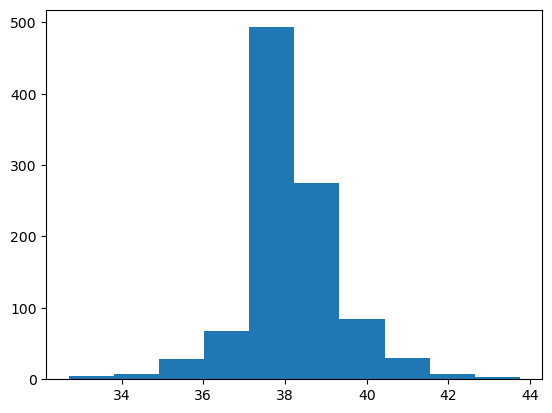

In [26]:
plt.hist(jobs_df['mean_mean_step'])

In [27]:
jobs_df.keys()

Index(['case_name', 'trial_id', 'timeres', 'spaceres', 'box_size', 'radius',
       'starting_lat', 'starting_lon', 'timewindow', 'child_of_interest',
       'n_steps_time', 'averaging_winners', 'snap_to_grid', 'montecarlo',
       'beta_softmax', 'eps_dbscan', 'min_samples_dbscan', 'score_mode',
       'gamma', 'alpha', 'prefer_sign', 'verbose', 'prob_rule',
       'winner_summary', 'cd_method', 'cd_kwargs.lambda_a',
       'cd_kwargs.l1_ratio', 'cd_kwargs.dependence_threshold',
       'cd_kwargs.max_iter', 'cd_kwargs.fit_intercept',
       'cd_kwargs.refit_ridge', 'cd_kwargs.ridge_alpha', 'n_members_requested',
       'n_members_success', 'n_members_failed', 'success_rate',
       'mean_traj_length', 'median_traj_length', 'std_traj_length',
       'min_traj_length', 'max_traj_length', 'mean_mean_step',
       'median_mean_step', 'std_mean_step', 'mean_net_displacement',
       'median_net_displacement', 'std_net_displacement',
       'n_members_with_valid_track', 'mean_final_dist_to_

In [28]:
# good_jobs = jobs_df[(jobs_df['mean_mean_step']>15)&(jobs_df['density_range_dominant_var']=='TMSO201')&\
#     (jobs_df['density_full::BURDENSO401']>jobs_df['density_full::AEROD_v'])]
# bad_jobs = jobs_df[(jobs_df['mean_mean_step']<15)|(jobs_df['density_range_dominant_var']!='TMSO201')|\
#     (jobs_df['density_full::BURDENSO401']<jobs_df['density_full::AEROD_v'])]

In [29]:
# good_jobs = jobs_df[(jobs_df['mean_mean_step']>12)&(jobs_df['density_range_dominant_var']=='TMSO201')&\
#     (jobs_df['density_range::BURDENSO401']>8000)&(jobs_df['mean_final_dist_to_volcano_km']<7000)]
# bad_jobs = jobs_df[(jobs_df['mean_mean_step']<12)|(jobs_df['density_range_dominant_var']!='TMSO201')|\
#     (jobs_df['density_range::BURDENSO401']<8000)|(jobs_df['mean_final_dist_to_volcano_km']>7000)]

In [30]:
# good_jobs = jobs_df[(jobs_df['mean_mean_step']>15)&(jobs_df['density_range_dominant_var']=='TMSO201')]
# bad_jobs = jobs_df[(jobs_df['mean_mean_step']<15)|(jobs_df['density_range_dominant_var']!='TMSO201')]

In [31]:
# good_jobs = jobs_df[(jobs_df['mean_mean_step']>10)]
# bad_jobs = jobs_df[(jobs_df['mean_mean_step']<10)]

In [32]:
good_jobs = jobs_df[(jobs_df['n_members_failed']<10)&(jobs_df['mean_traj_length']>15)]
bad_jobs = jobs_df[(jobs_df['n_members_failed']>10)|(jobs_df['mean_traj_length']<15)]

In [33]:
len(good_jobs)/len(jobs_df)

0.999

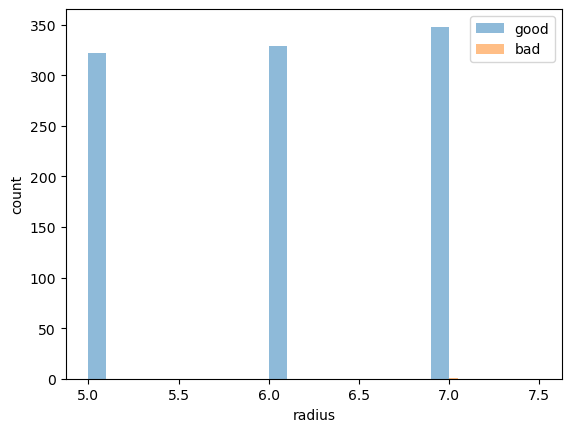

In [34]:
plt.hist(good_jobs.radius, bins=20, alpha=0.5, label="good")
plt.hist(bad_jobs.radius, bins=20, alpha=0.5, label="bad")

plt.legend()
plt.xlabel("radius")
plt.ylabel("count")
plt.show()

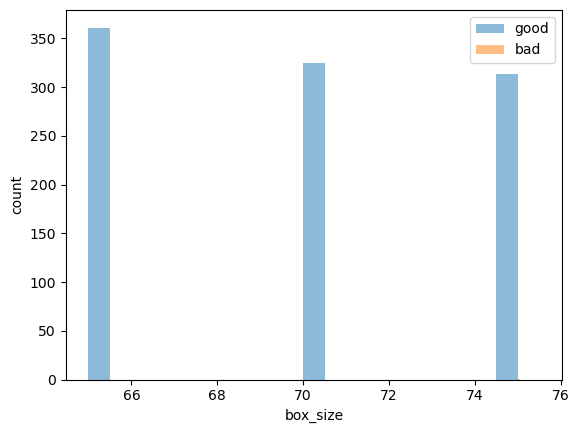

In [35]:
plt.hist(good_jobs.box_size, bins=20, alpha=0.5, label="good")
plt.hist(bad_jobs.box_size, bins=20, alpha=0.5, label="bad")

plt.legend()
plt.xlabel("box_size")
plt.ylabel("count")
plt.show()

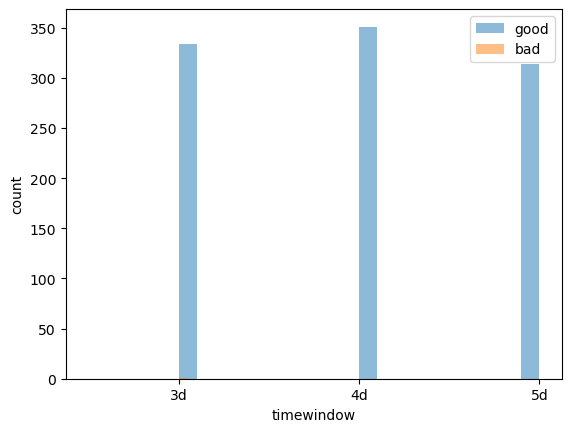

In [36]:
plt.hist(good_jobs.timewindow, bins=20, alpha=0.5, label="good")
plt.hist(bad_jobs.timewindow, bins=20, alpha=0.5, label="bad")

plt.legend()
plt.xlabel("timewindow")
plt.ylabel("count")
plt.show()

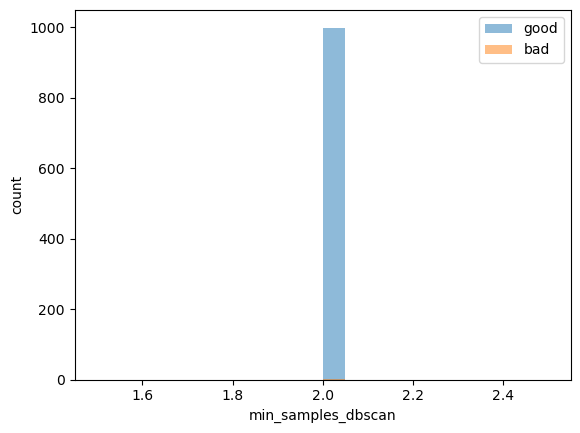

In [37]:
plt.hist(good_jobs.min_samples_dbscan, bins=20, alpha=0.5, label="good")
plt.hist(bad_jobs.min_samples_dbscan, bins=20, alpha=0.5, label="bad")

plt.legend()
plt.xlabel("min_samples_dbscan")
plt.ylabel("count")
plt.show()

(array([971.,   0.,   0.,   3.,   0.,   0.,   0.,   0.,   0.,  25.]),
 array([1. , 1.3, 1.6, 1.9, 2.2, 2.5, 2.8, 3.1, 3.4, 3.7, 4. ]),
 <BarContainer object of 10 artists>)

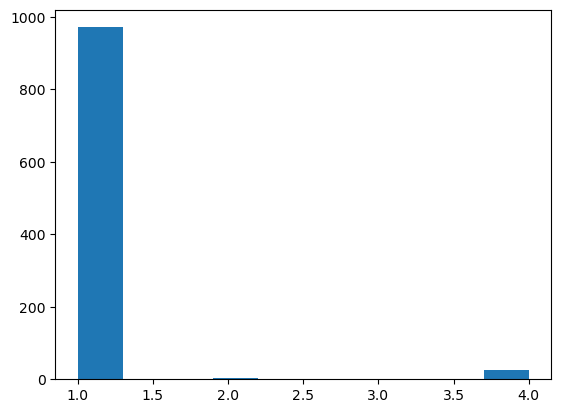

In [38]:
plt.hist(good_jobs['most_repeated_parent_final'])

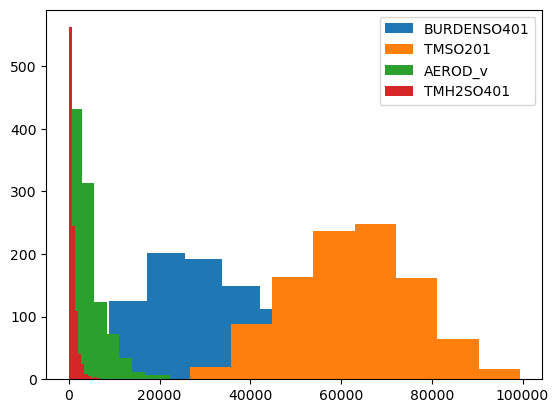

In [39]:
plt.hist(jobs_df['density_range::BURDENSO401'],label='BURDENSO401')
plt.hist(jobs_df['density_range::TMSO201'],label='TMSO201')
plt.hist(jobs_df['density_range::AEROD_v'],label='AEROD_v')
plt.hist(jobs_df['density_range::TMH2SO401'],label='TMH2SO401')
plt.legend()
# plt.hist()

In [40]:
def regrid_global_nearest(
    da,
    dlat=2.5,
    dlon=2.5,
    lat_name="lat",
    lon_name="lon",
):
    """
    Regrid a global DataArray to a regular lat-lon grid using nearest-neighbor interpolation.
    """
    da = da.sortby(lat_name).sortby(lon_name)

    new_lat = np.arange(-90 + dlat / 2, 90, dlat)
    new_lon = np.arange(0 + dlon / 2, 360, dlon)

    new_lat = new_lat[(new_lat >= -90) & (new_lat <= 90)]
    new_lon = new_lon[(new_lon >= 0) & (new_lon < 360)]

    da_out = da.interp(
        {
            lat_name: xr.DataArray(new_lat, dims=lat_name),
            lon_name: xr.DataArray(new_lon, dims=lon_name),
        },
        method="nearest",
    )
    return da_out

# --------------------------------------------------
# Pinatubo data
# --------------------------------------------------
PATH_FILES_PINATUBO = "/glade/derecho/scratch/jhayron/DataCaStLeBTs/Sandia/"
# --------------------------------------------------
# Pinatubo event definition
# --------------------------------------------------
event_lat_pinatubo = 15
event_lon_pinatubo = -160
date_end_pinatubo = "1991-07-02 00:00:00"

volcano_lat_pinatubo = 15.13
volcano_lon_pinatubo = 120.35

extent_pinatubo=(-180, 180, -25, 55)
res_pinatubo = 4

names_vars_pinatubo = ["TMSO201", "BURDENSO401", "TMH2SO401", "AEROD_v"]

vars_list_pinatubo = []
for var in names_vars_pinatubo:
    vars_list_pinatubo.append(
        xr.open_dataset(f"{PATH_FILES_PINATUBO}{var}_199101_199112.nc")[var]
    )

full_data_pinatubo = xr.concat(vars_list_pinatubo, dim="var").transpose("var", "lat", "lon", "time")
full_data_pinatubo = full_data_pinatubo.assign_coords(var=names_vars_pinatubo)
full_data_pinatubo["time"] = full_data_pinatubo.indexes["time"].to_datetimeindex()

full_data_pinatubo = regrid_global_nearest(full_data_pinatubo, dlat=res_pinatubo, dlon=res_pinatubo)

full_data_pinatubo = (
    full_data_pinatubo - full_data_pinatubo.mean("time")
) / full_data_pinatubo.std("time")

full_data_pinatubo = full_data_pinatubo.assign_coords(
    lon=(full_data_pinatubo.lon % 360)
).sortby("lon")

full_data_pinatubo

/glade/derecho/scratch/jhayron/tmp/ipykernel_15626/2404225399.py:55: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  full_data_pinatubo["time"] = full_data_pinatubo.indexes["time"].to_datetimeindex()


<xarray.DataArray 'TMSO201' (var: 4, lat: 45, lon: 90, time: 215)> Size: 14MB
array([[[[-0.933959  , -0.933959  , -0.933959  , ..., -0.59906757,
          -0.61470366, -0.63109446],
         [-0.93398374, -0.93398374, -0.93398374, ..., -0.59909976,
          -0.61473346, -0.63114667],
         [-0.9340373 , -0.9340373 , -0.9340373 , ..., -0.59916955,
          -0.6147981 , -0.63126034],
         ...,
         [-0.9340651 , -0.9340651 , -0.9340651 , ..., -0.59783554,
          -0.6085517 , -0.6323178 ],
         [-0.9340003 , -0.9340003 , -0.9340003 , ..., -0.59780073,
          -0.6085092 , -0.632189  ],
         [-0.9339665 , -0.9339665 , -0.9339665 , ..., -0.5977825 ,
          -0.60848695, -0.6321221 ]],

        [[-0.9294266 , -0.9294266 , -0.9294266 , ..., -0.59241617,
          -0.60925806, -0.60572994],
         [-0.9294266 , -0.9294266 , -0.9294266 , ..., -0.59241617,
          -0.60925806, -0.60572994],
         [-0.9294266 , -0.9294266 , -0.9294266 , ..., -0.59241617,
          -0.60925806, -0.60572994],
...
         [-1.0783062 , -0.8558682 , -1.6571751 , ...,         nan,
                  nan,         nan],
         [-1.090956  , -0.847335  , -1.6661686 , ...,         nan,
                  nan,         nan],
         [-1.097119  , -0.842623  , -1.6702384 , ...,         nan,
                  nan,         nan]],

        [[-0.961256  , -0.92400604, -1.2024854 , ...,         nan,
                  nan,         nan],
         [-0.961256  , -0.92400604, -1.2024854 , ...,         nan,
                  nan,         nan],
         [-0.961256  , -0.92400604, -1.2024854 , ...,         nan,
                  nan,         nan],
         ...,
         [-1.2668186 , -1.4070921 , -1.2823398 , ...,         nan,
                  nan,         nan],
         [-1.2668186 , -1.4070921 , -1.2823398 , ...,         nan,
                  nan,         nan],
         [-1.2668186 , -1.4070921 , -1.2823398 , ...,         nan,
                  nan,         nan]]]], dtype=float32)
Coordinates:
  * var      (var) <U11 176B 'TMSO201' 'BURDENSO401' 'TMH2SO401' 'AEROD_v'
  * time     (time) datetime64[ns] 2kB 1991-06-01 1991-06-02 ... 1992-01-01
  * lat      (lat) float64 360B -88.0 -84.0 -80.0 -76.0 ... 76.0 80.0 84.0 88.0
  * lon      (lon) float64 720B 2.0 6.0 10.0 14.0 ... 346.0 350.0 354.0 358.0

In [41]:
good_jobs

,case_name,trial_id,timeres,spaceres,box_size,radius,starting_lat,starting_lon,timewindow,child_of_interest,...,density_full_dominant_parent,density_full_dominant_var,density_range_dominant_parent,density_range_dominant_var,elapsed_sec,status,ok,error,bundle_npz,bundle_json
0,pinatubo,391,1d,4,65,7,15.0,-160.0,3d,4,...,1,TMSO201,1,TMSO201,44.348664,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
1,pinatubo,673,1d,4,65,7,15.0,-160.0,4d,4,...,1,TMSO201,1,TMSO201,41.657658,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
2,pinatubo,205,1d,4,70,7,15.0,-160.0,5d,4,...,1,TMSO201,1,TMSO201,49.557200,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
3,pinatubo,264,1d,4,65,7,15.0,-160.0,4d,4,...,1,TMSO201,1,TMSO201,41.067552,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
4,pinatubo,918,1d,4,65,7,15.0,-160.0,3d,4,...,1,TMSO201,1,TMSO201,42.803260,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,pinatubo,939,1d,4,75,7,15.0,-160.0,3d,4,...,1,TMSO201,1,TMSO201,51.581867,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
996,pinatubo,8,1d,4,65,5,15.0,-160.0,3d,4,...,1,TMSO201,1,TMSO201,46.497270,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
997,pinatubo,171,1d,4,75,5,15.0,-160.0,4d,4,...,2,BURDENSO401,2,BURDENSO401,61.330708,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
998,pinatubo,948,1d,4,70,5,15.0,-160.0,3d,4,...,1,TMSO201,1,TMSO201,49.732701,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...


In [42]:
pinatubo_trial_ids = good_jobs.trial_id.values
jobs_df_pinatubo = jobs_df.copy()
members_df_pinatubo = members_df.copy()
volcano_lon = lon0360_to_m180_180(volcano_lon_pinatubo)
volcano_lat = volcano_lat_pinatubo

# Final plots

In [112]:
import os
import matplotlib as mpl
import matplotlib.font_manager as fm
# ------------------------------------------------------------
# Font setup (Helvetica Regular + Bold)
# ------------------------------------------------------------
font_dir = "/glade/u/home/jhayron/Causality_CaStLe/PaperCausalBTs/Helvetica"

regular_font = os.path.join(font_dir, "Helvetica.ttf")
bold_font = os.path.join(font_dir, "Helvetica-Bold.ttf")

if os.path.exists(regular_font):
    fm.fontManager.addfont(regular_font)

if os.path.exists(bold_font):
    fm.fontManager.addfont(bold_font)

mpl.rcParams["font.family"] = "Helvetica"
mpl.rcParams["font.weight"] = "regular"

mpl.rcParams.update({
    # --------------------------------------------------
    # FONT FAMILY
    # --------------------------------------------------
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],

    # --------------------------------------------------
    # WEIGHTS
    # --------------------------------------------------
    "font.weight": "regular",
    "axes.titleweight": "bold",
    "axes.labelweight": "regular",

    # --------------------------------------------------
    # FONT SIZES (optional but recommended)
    # --------------------------------------------------
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,

    # --------------------------------------------------
    # IMPORTANT: MATH TEXT → match Helvetica
    # --------------------------------------------------
    "mathtext.fontset": "custom",
    "mathtext.rm": "Helvetica",
    "mathtext.it": "Helvetica:italic",
    "mathtext.bf": "Helvetica:bold",
    "mathtext.cal": "Helvetica",   # ← THIS fixes the warning

    # --------------------------------------------------
    # PDF / VECTOR EXPORT (VERY IMPORTANT FOR PAPERS)
    # --------------------------------------------------
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

mpl.rcParams.update({

    # -------------------------
    # FONT FAMILY
    # -------------------------
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],

    # -------------------------
    # BASE SIZE (master control)
    # -------------------------
    "font.size": 11,

    # -------------------------
    # TITLES
    # -------------------------
    "axes.titlesize": 13,
    "axes.titleweight": "bold",

    # -------------------------
    # AXIS LABELS
    # -------------------------
    "axes.labelsize": 11,

    # -------------------------
    # TICKS
    # -------------------------
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    # -------------------------
    # LEGENDS
    # -------------------------
    "legend.fontsize": 9,

    # -------------------------
    # COLORBAR
    # -------------------------
    "axes.labelweight": "regular",

    # -------------------------
    # MATH TEXT (critical)
    # -------------------------
    "mathtext.fontset": "custom",
    "mathtext.rm": "Helvetica",
    "mathtext.it": "Helvetica:italic",
    "mathtext.bf": "Helvetica:bold",
    "mathtext.cal": "Helvetica",

    # -------------------------
    # VECTOR EXPORT
    # -------------------------
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

In [160]:
# ============================================================
# CLEAN Fig. 3 split functions: Debby + Pinatubo
# ============================================================

import copy
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection
from matplotlib.patches import Circle
from matplotlib.ticker import FuncFormatter


FIG3_LABELS = {
    "Tb": "Brightness temperature",
    "vo": "Mid-level vorticity",
    "precip": "Precipitation",
    "TMSO201": "SO$_2$",
    "BURDENSO401": "SO$_4$",
    "TMH2SO401": "H$_2$SO$_4$",
    "AEROD_v": "AOD",
}


def _fig3_style_geo_ax(ax, extent, add_grid=True):
    geo = ccrs.PlateCarree()
    ax.set_extent(extent, crs=geo)
    ax.set_facecolor("white")
    ax.add_feature(cfeature.LAND, facecolor="white", edgecolor="none", zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.65, zorder=3)
    ax.add_feature(cfeature.BORDERS, linewidth=0.35, zorder=3)

    if add_grid:
        gl = ax.gridlines(
            draw_labels=False,
            linewidth=0.28,
            alpha=0.28,
            linestyle="-",
        )
        gl.top_labels = False
        gl.right_labels = False


def _load_trial_ensemble_and_params(trial_id, jobs_df_case):
    row, bundle_npz, bundle_meta = load_bundle_for_trial(trial_id, jobs_df_case)
    params = copy.deepcopy(bundle_meta["params"])
    ensemble = reconstruct_ensemble_from_bundle(bundle_npz)
    return row, params, ensemble


def _collect_case_members_and_boxsize(trial_ids, jobs_df_case):
    all_members = []
    box_sizes = []

    for tid in list(trial_ids):
        _, params, ens = _load_trial_ensemble_and_params(tid, jobs_df_case)
        all_members.extend(ens)
        box_sizes.append(float(params["box_size"]))

    if len(all_members) == 0:
        raise ValueError("No valid ensemble members found.")

    return all_members, float(np.median(box_sizes))


def _compute_density_list_case(
    *,
    full_data_run,
    ensemble_results,
    box_size_deg,
    panel_vars,
    density_percentile_cap=99.0,
):
    ens_trim = drop_initial_steps_from_ensemble(ensemble_results, n_skip=1)

    dens_plot_list = []
    vmax_candidates = []

    for v in panel_vars:
        dens = compute_density_for_var_multi(
            full_data_run=full_data_run,
            ensemble_results=ens_trim,
            box_size_deg=box_size_deg,
            var_name=v,
        )
        dens_plot = density_for_plotting_m180_180(dens)
        dens_plot_list.append(dens_plot)

        vals = np.asarray(dens_plot.values, dtype=float)
        vals = vals[np.isfinite(vals)]
        vals = vals[vals > 0]
        if vals.size:
            vmax_candidates.append(np.percentile(vals, density_percentile_cap))

    vmax = max(vmax_candidates) if len(vmax_candidates) else 1.0
    return dens_plot_list, vmax


def _draw_example_ensemble_panel_fig3(
    ax,
    ensemble_results,
    full_data_run,
    *,
    title,
    extent,
    timeres=1.0,
    cmap_name="managua",
    lag_vmin=0.0,
    lag_vmax=None,
    line_alpha=0.42,
    line_width=0.75,
    point_alpha=0.70,
    point_size=7,
    point_stride=1,
    event_lon=None,
    event_lat=None,
    event_marker="*",
    observed_lon=None,
    observed_lat=None,
    observed_stride=2,
    observed_marker="X",
):
    geo = ccrs.PlateCarree()
    _fig3_style_geo_ax(ax, extent, add_grid=True)

    successful = [r for r in ensemble_results if len(np.asarray(r["centers"])) > 0]
    if len(successful) == 0:
        raise ValueError("No valid ensemble members in selected example trial.")

    max_steps = max(len(np.asarray(r["centers"])) for r in successful)
    if lag_vmax is None:
        lag_vmax = float(max_steps - 1) * float(timeres)

    cmap = plt.get_cmap(cmap_name)
    norm = mpl.colors.Normalize(vmin=float(lag_vmin), vmax=float(lag_vmax))

    for res in successful:
        centers = np.asarray(res["centers"], dtype=float)
        parents = np.asarray(res["parents"], dtype=int)

        nT = min(len(centers), len(parents))
        if nT <= 0:
            continue

        centers = centers[:nT]
        lats = centers[:, 0]
        lons = lon0360_to_m180_180(centers[:, 1] % 360.0)
        tback = np.arange(nT, dtype=float) * float(timeres)

        if nT > 1:
            points = np.column_stack([lons, lats]).reshape(-1, 1, 2)
            segments = np.concatenate([points[:-1], points[1:]], axis=1)

            lc = LineCollection(
                segments,
                cmap=cmap,
                norm=norm,
                linewidths=line_width,
                alpha=line_alpha,
                zorder=2,
                transform=geo,
            )
            lc.set_array(tback[:-1])
            ax.add_collection(lc)

        idx = np.arange(nT)[::max(1, int(point_stride))]
        ax.scatter(
            lons[idx],
            lats[idx],
            c=tback[idx],
            cmap=cmap,
            norm=norm,
            s=point_size,
            marker="o",
            alpha=point_alpha,
            edgecolor="none",
            transform=geo,
            zorder=4,
        )

    if observed_lon is not None and observed_lat is not None:
        idx = np.arange(len(observed_lon))[::observed_stride]
        ax.plot(
            np.asarray(observed_lon)[idx],
            np.asarray(observed_lat)[idx],
            "-",
            color="0.1",
            linewidth=1.0,
            alpha=0.9,
            transform=geo,
            zorder=6,
        )
        ax.scatter(
            np.asarray(observed_lon)[idx],
            np.asarray(observed_lat)[idx],
            marker=observed_marker,
            s=26,
            color="white",
            edgecolor="0.1",
            linewidth=0.55,
            transform=geo,
            zorder=7,
        )

    if event_lon is not None and event_lat is not None:
        ax.scatter(
            event_lon,
            event_lat,
            marker=event_marker,
            s=90,
            color="gold",
            edgecolor="k",
            linewidth=0.6,
            transform=geo,
            zorder=10,
        )

    ax.set_title(title, loc="left", fontsize=13, fontweight="bold", pad=3)

    return norm, cmap


def _draw_distribution_hist_fig3(
    ax,
    vals,
    *,
    title,
    xlabel,
    color="#5a284d",
    bins=28,
):
    vals = pd.to_numeric(pd.Series(vals), errors="coerce")
    vals = vals[np.isfinite(vals)].values

    if len(vals) == 0:
        ax.text(0.5, 0.5, "No valid values", ha="center", va="center", transform=ax.transAxes)
    else:
        ax.hist(
            vals,
            bins=bins,
            histtype="stepfilled",
            alpha=0.55,
            linewidth=1.4,
            color=color,
            edgecolor="0.15",
        )
        m = np.nanmean(vals)
        ax.axvline(
            m,
            color="0.15",
            linestyle="--",
            linewidth=1.2,
            label=f"Mean = {m:.1f}",
        )
        ax.legend(frameon=True, fontsize=8, loc="upper right")

    ax.set_title(title, loc="left", fontsize=13, fontweight="bold", pad=4)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel("Count", fontsize=11,labelpad=2)
    ax.grid(alpha=0.22, linewidth=0.5)
    ax.tick_params(labelsize=10)


def _draw_relevance_boxplots_fig3(
    ax,
    jobs_sel,
    *,
    density_cols,
    title,
    ylabel,
    colors,
    scale_millions=False,
):
    data = []
    labels = []

    for col, label in density_cols:
        if col not in jobs_sel.columns:
            continue

        vals = pd.to_numeric(jobs_sel[col], errors="coerce")
        vals = vals[np.isfinite(vals)].values

        if len(vals):
            data.append(vals)
            labels.append(label)

    if len(data) == 0:
        ax.text(0.5, 0.5, "No valid density columns", ha="center", va="center", transform=ax.transAxes)
    else:
        bp = ax.boxplot(
            data,
            tick_labels=labels,
            patch_artist=True,
            widths=0.58,
            showfliers=True,
            medianprops=dict(color="0.15", linewidth=1.4),
            whiskerprops=dict(color="0.2", linewidth=1.0),
            capprops=dict(color="0.2", linewidth=1.0),
            boxprops=dict(linewidth=1.0, color="0.2"),
        )

        for patch, color in zip(bp["boxes"], colors[:len(bp["boxes"])]):
            patch.set_facecolor(color)
            patch.set_alpha(0.45)
            patch.set_edgecolor(color)

    if scale_millions:
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1e6:g}"))
        ylabel = "Integrated density ($10^6$)"
    else:
        ax.ticklabel_format(axis="y", style="plain", useOffset=False)

    ax.set_title(title, loc="left", fontsize=13, fontweight="bold", pad=4)
    ax.set_ylabel(ylabel, fontsize=11, labelpad=2)
    ax.grid(alpha=0.22, linewidth=0.5)
    ax.tick_params(labelsize=10)
    ax.set_xticklabels(labels, rotation=18, ha="right", fontsize=10)


def _draw_density_map_fig3(
    ax,
    dens_plot,
    *,
    title,
    extent,
    cmap="BuPu",
    vmin=0,
    vmax=None,
    alpha=0.55,
    event_lon=None,
    event_lat=None,
    event_marker="*",
    observed_lon=None,
    observed_lat=None,
    observed_stride=2,
    highlight_circle=None,
):
    geo = ccrs.PlateCarree()
    _fig3_style_geo_ax(ax, extent, add_grid=True)

    lon_name = "lon" if "lon" in dens_plot.coords else "longitude"
    lat_name = "lat" if "lat" in dens_plot.coords else "latitude"

    lonp = np.asarray(dens_plot[lon_name].values, dtype=float)
    latp = np.asarray(dens_plot[lat_name].values, dtype=float)
    H = np.asarray(dens_plot.values, dtype=float)

    mesh = ax.pcolormesh(
        lonp,
        latp,
        H,
        transform=geo,
        shading="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        alpha=alpha,
        zorder=1,
        rasterized=True,
    )

    if observed_lon is not None and observed_lat is not None:
        idx = np.arange(len(observed_lon))[::observed_stride]
        ax.plot(
            np.asarray(observed_lon)[idx],
            np.asarray(observed_lat)[idx],
            "-",
            color="0.1",
            linewidth=1.0,
            alpha=0.9,
            transform=geo,
            zorder=6,
        )
        ax.scatter(
            np.asarray(observed_lon)[idx],
            np.asarray(observed_lat)[idx],
            s=11,
            color="0.1",
            marker="o",
            transform=geo,
            zorder=7,
        )

    if highlight_circle is not None:
        circ = Circle(
            (highlight_circle.get("lon", -17), highlight_circle.get("lat", 15)),
            radius=highlight_circle.get("radius", 8),
            facecolor="none",
            edgecolor=highlight_circle.get("edgecolor", "0.1"),
            linewidth=highlight_circle.get("linewidth", 1.5),
            linestyle=highlight_circle.get("linestyle", "--"),
            alpha=highlight_circle.get("alpha", 0.95),
            transform=geo,
            zorder=9,
        )
        ax.add_patch(circ)

    if event_lon is not None and event_lat is not None:
        ax.scatter(
            event_lon,
            event_lat,
            marker=event_marker,
            s=70,
            color="gold",
            edgecolor="k",
            linewidth=0.55,
            transform=geo,
            zorder=10,
        )

    ax.set_title(title, loc="left", fontsize=12.5, fontweight="bold", pad=4)
    return mesh


def make_fig3_debby_split(
    *,
    example_trial_id,
    debby_trial_ids,
    debby_jobs_df,
    debby_members_df,
    full_data_debby,
    extent_debby,
    storm_lon,
    storm_lat,
    storm_hours_back,
    event_lon_debby,
    event_lat_debby,
    density_vmax=15000,
    density_cmap="BuPu",
    density_alpha=0.55,
    cmap_name="managua",
    figsize=(14, 6.4),
):
    geo = ccrs.PlateCarree()

    _, params_ex, ensemble_ex = _load_trial_ensemble_and_params(example_trial_id, debby_jobs_df)
    all_members, box_size = _collect_case_members_and_boxsize(debby_trial_ids, debby_jobs_df)

    panel_vars = ["precip", "Tb", "vo"]
    dens_list, _ = _compute_density_list_case(
        full_data_run=full_data_debby,
        ensemble_results=all_members,
        box_size_deg=box_size,
        panel_vars=panel_vars,
        density_percentile_cap=99.0,
    )

    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(
        4,
        12,
        figure=fig,
        height_ratios=[1.0, 0.055, 1.0, 0.045],
        left=0.045,
        right=0.965,
        top=0.94,
        bottom=0.095,
        wspace=0.8,
        hspace=0.16,
    )

    axA = fig.add_subplot(gs[0, 0:4], projection=geo)
    axB = fig.add_subplot(gs[0, 4:8])
    axC = fig.add_subplot(gs[0, 8:12])
    
    axD = fig.add_subplot(gs[2, 0:4], projection=geo)
    axE = fig.add_subplot(gs[2, 4:8], projection=geo)
    axF = fig.add_subplot(gs[2, 8:12], projection=geo)
    
    cax_den = fig.add_axes([0.3565, 0.12, 0.30, 0.018])

    lag_norm, lag_cmap = _draw_example_ensemble_panel_fig3(
        axA,
        ensemble_ex,
        full_data_debby,
        title=f"A. TraCE-ST ensemble",
        extent=extent_debby,
        timeres=1.0,
        cmap_name=cmap_name,
        lag_vmin=0,
        lag_vmax=360,
        line_alpha=0.42,
        line_width=0.75,
        point_alpha=0.70,
        point_size=7,
        point_stride=6,
        event_lon=event_lon_debby,
        event_lat=event_lat_debby,
        observed_lon=storm_lon,
        observed_lat=storm_lat,
        observed_stride=2,
        observed_marker="X",
    )

    members_sel = debby_members_df[debby_members_df["trial_id"].isin(debby_trial_ids)].copy()
    _draw_distribution_hist_fig3(
        axB,
        members_sel["track_dist_km_mean"] if "track_dist_km_mean" in members_sel.columns else [],
        title="B. Distance from official track",
        xlabel="Member mean distance from observed track (km)",
        color="#5f93d1",
    )

    jobs_sel = debby_jobs_df[debby_jobs_df["trial_id"].isin(debby_trial_ids)].copy()
    _draw_relevance_boxplots_fig3(
        axC,
        jobs_sel,
        density_cols=[
            ("density_range::precip", "Precip."),
            ("density_range::Tb", "BT"),
            ("density_range::vo", "Vorticity"),
        ],
        title="C. TraCE-ST causal relevance",
        ylabel="Integrated density",
        colors=["#c98245", "#5a284d", "#5f93d1"],
        scale_millions=True,
    )

    density_mesh = None
    for ax, v, letter in zip([axD, axE, axF], panel_vars, ["D", "E", "F"]):
        density_mesh = _draw_density_map_fig3(
            ax,
            dens_list[panel_vars.index(v)],
            title=f"{letter}. {FIG3_LABELS[v]}",
            extent=extent_debby,
            cmap=density_cmap,
            vmin=0,
            vmax=density_vmax,
            alpha=density_alpha,
            event_lon=event_lon_debby,
            event_lat=event_lat_debby,
            observed_lon=storm_lon,
            observed_lat=storm_lat,
            observed_stride=2,
            highlight_circle={
                "lon": -15,
                "lat": 18,
                "radius": 8,
                "edgecolor": "0.1",
                "linewidth": 1.5,
                "linestyle": "--",
                "alpha": 0.95,
            } if letter == "F" else None,
        )

    posA = axA.get_position()
    cax_lag = fig.add_axes([
        posA.x0 + 0.16 * posA.width,
        posA.y0 - 0.03,
        0.68 * posA.width,
        0.011,
    ])
    sm = mpl.cm.ScalarMappable(norm=lag_norm, cmap=lag_cmap)
    sm.set_array([])
    cb = fig.colorbar(sm, cax=cax_lag, orientation="horizontal")
    cb.set_label("Hours back from target", fontsize=10.5, labelpad=0.1)
    cb.ax.tick_params(labelsize=9.5, pad=1)
    cb.outline.set_linewidth(0.6)

    cbden = fig.colorbar(density_mesh, cax=cax_den, orientation="horizontal")
    cbden.set_label("Integrated trajectory density", fontsize=10.5, labelpad=0)
    cbden.ax.tick_params(labelsize=9.5, pad=1)
    cbden.outline.set_linewidth(0.6)

    return fig


def make_fig3_pinatubo_split(
    *,
    example_trial_id,
    pinatubo_trial_ids,
    pinatubo_jobs_df,
    pinatubo_members_df,
    full_data_pinatubo,
    extent_pinatubo,
    volcano_lon,
    volcano_lat,
    density_vmax=110000,
    density_cmap="BuPu",
    density_alpha=0.55,
    cmap_name="managua",
    figsize=(14, 6.4),
):
    geo = ccrs.PlateCarree()

    _, params_ex, ensemble_ex = _load_trial_ensemble_and_params(example_trial_id, pinatubo_jobs_df)
    all_members, box_size = _collect_case_members_and_boxsize(pinatubo_trial_ids, pinatubo_jobs_df)

    panel_vars = ["TMSO201", "BURDENSO401", "TMH2SO401", "AEROD_v"]
    dens_list, _ = _compute_density_list_case(
        full_data_run=full_data_pinatubo,
        ensemble_results=all_members,
        box_size_deg=box_size,
        panel_vars=panel_vars,
        density_percentile_cap=99.0,
    )

    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(
        4,
        16,
        figure=fig,
        height_ratios=[1.0, 0.055, 1.0, 0.045],
        left=0.045,
        right=0.965,
        top=0.94,
        bottom=0.095,
        wspace=2.7,
        hspace=0.16,
    )

    axA = fig.add_subplot(gs[0, 0:6], projection=geo)
    axB = fig.add_subplot(gs[0, 6:11])
    axC = fig.add_subplot(gs[0, 11:16])

    
    axD = fig.add_subplot(gs[2, 0:4], projection=geo)
    axE = fig.add_subplot(gs[2, 4:8], projection=geo)
    axF = fig.add_subplot(gs[2, 8:12], projection=geo)
    axG = fig.add_subplot(gs[2, 12:16], projection=geo)
    
    cax_den = fig.add_axes([0.34, 0.16, 0.32, 0.018])

    lag_norm, lag_cmap = _draw_example_ensemble_panel_fig3(
        axA,
        ensemble_ex,
        full_data_pinatubo,
        title=f"A. TraCE-ST ensemble",
        extent=extent_pinatubo,
        timeres=1.0,
        cmap_name=cmap_name,
        lag_vmin=0,
        lag_vmax=16,
        line_alpha=0.42,
        line_width=0.75,
        point_alpha=0.70,
        point_size=7,
        point_stride=1,
        event_lon=volcano_lon,
        event_lat=volcano_lat,
        event_marker="*",
    )

    members_sel = pinatubo_members_df[pinatubo_members_df["trial_id"].isin(pinatubo_trial_ids)].copy()
    _draw_distribution_hist_fig3(
        axB,
        members_sel["final_dist_to_volcano_km"] if "final_dist_to_volcano_km" in members_sel.columns else [],
        title="B. Final distance to volcano",
        xlabel="Final distance to Mount Pinatubo (km)",
        color="#c98245",
    )

    jobs_sel = pinatubo_jobs_df[pinatubo_jobs_df["trial_id"].isin(pinatubo_trial_ids)].copy()
    _draw_relevance_boxplots_fig3(
        axC,
        jobs_sel,
        density_cols=[
            ("density_range::TMSO201", "SO$_2$"),
            ("density_range::BURDENSO401", "SO$_4$"),
            ("density_range::TMH2SO401", "H$_2$SO$_4$"),
            ("density_range::AEROD_v", "AOD"),
        ],
        title="C. TraCE-ST causal relevance",
        ylabel="Integrated density",
        colors=["#c98245", "#5a284d", "#5f93d1", "0.35"],
        scale_millions=False,
    )

    density_mesh = None
    for ax, v, letter in zip([axD, axE, axF, axG], panel_vars, ["D", "E", "F", "G"]):
        density_mesh = _draw_density_map_fig3(
            ax,
            dens_list[panel_vars.index(v)],
            title=f"{letter}. {FIG3_LABELS[v]}",
            extent=extent_pinatubo,
            cmap=density_cmap,
            vmin=0,
            vmax=density_vmax,
            alpha=density_alpha,
            event_lon=volcano_lon,
            event_lat=volcano_lat,
            event_marker="*",
        )

    posA = axA.get_position()
    cax_lag = fig.add_axes([
        posA.x0 + 0.16 * posA.width,
        posA.y0 - 0.042,
        0.68 * posA.width,
        0.011,
    ])
    sm = mpl.cm.ScalarMappable(norm=lag_norm, cmap=lag_cmap)
    sm.set_array([])
    cb = fig.colorbar(sm, cax=cax_lag, orientation="horizontal")
    cb.set_label("Days back from target", fontsize=10.5, labelpad=0.1)
    cb.ax.tick_params(labelsize=9.5, pad=1)
    cb.outline.set_linewidth(0.6)

    cbden = fig.colorbar(density_mesh, cax=cax_den, orientation="horizontal")
    cbden.set_label("Integrated trajectory density", fontsize=10.5, labelpad=0)
    cbden.ax.tick_params(labelsize=9.5, pad=1)
    cbden.outline.set_linewidth(0.6)

    return fig

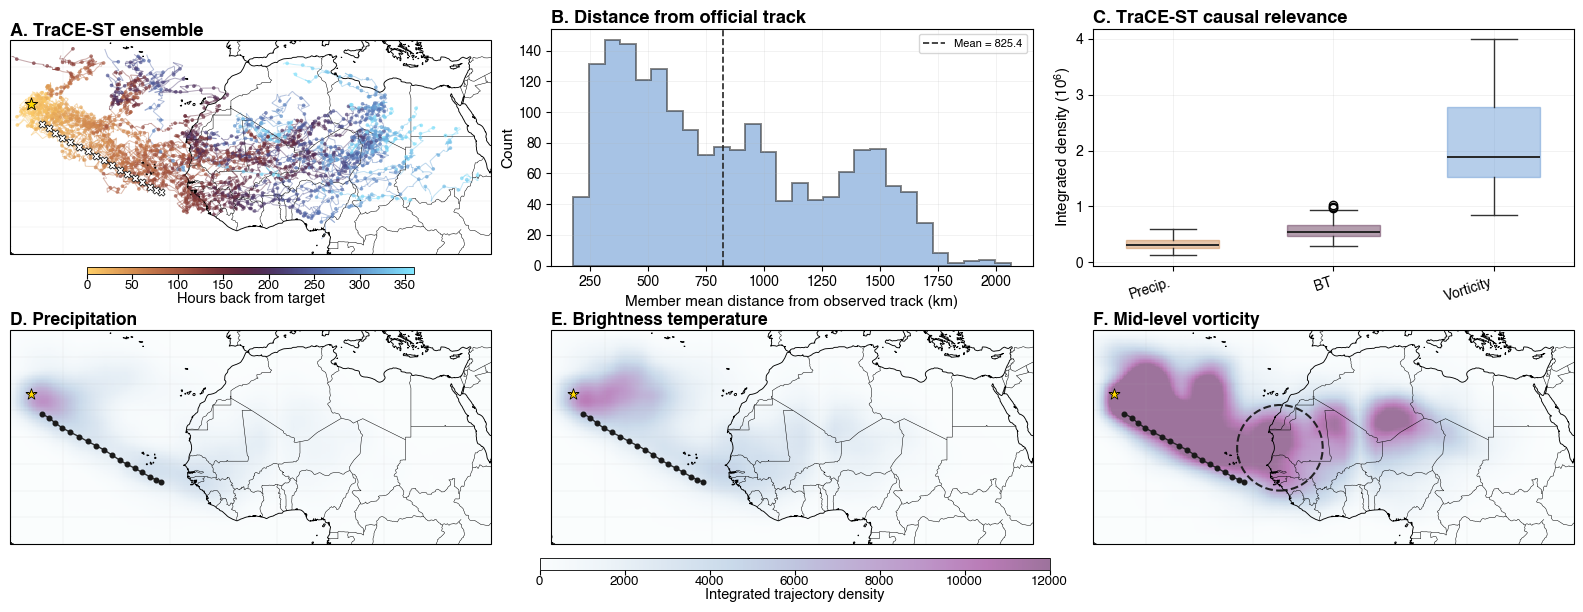

In [216]:
fig3_debby = make_fig3_debby_split(
    example_trial_id=246,
    debby_trial_ids=debby_trial_ids,
    debby_jobs_df=jobs_df_debby,
    debby_members_df=members_df_debby,
    full_data_debby=full_data_debby,
    extent_debby=extent_debby,
    storm_lon=storm_lon,
    storm_lat=storm_lat,
    storm_hours_back=storm_hours_back,
    event_lon_debby=event_lon_debby,
    event_lat_debby=event_lat_debby,
    density_vmax=12000,
    density_cmap="BuPu",
    density_alpha=0.55,
    cmap_name="managua",
    figsize=(17, 6.6),
)

plt.show()

fig3_debby.savefig("fig_debby.pdf", bbox_inches="tight")

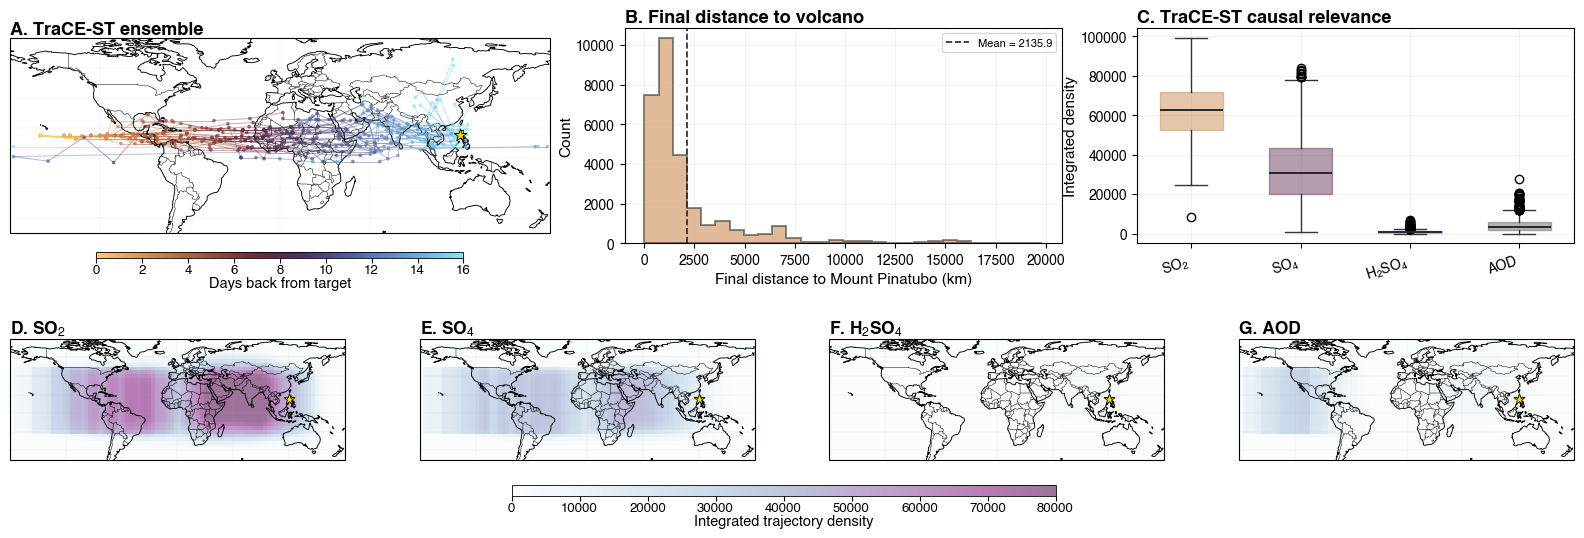

In [189]:
fig3_pinatubo = make_fig3_pinatubo_split(
    example_trial_id=929,
    pinatubo_trial_ids=pinatubo_trial_ids,
    pinatubo_jobs_df=jobs_df_pinatubo,
    pinatubo_members_df=members_df_pinatubo,
    full_data_pinatubo=full_data_pinatubo,
    extent_pinatubo=(-180, 180, -50, 80),
    volcano_lon=volcano_lon,
    volcano_lat=volcano_lat,
    density_vmax=80000,
    density_cmap="BuPu",
    density_alpha=0.55,
    cmap_name="managua",
    figsize=(17, 6),
)

plt.show()

fig3_pinatubo.savefig("fig_pinatubo.pdf", bbox_inches="tight")

# supplementary

In [178]:
# ============================================================
# Supplementary figures:
# 12 randomly selected example ensembles for Debby / Pinatubo
# ============================================================

def plot_random_trial_ensemble_gallery_fig3(
    *,
    trial_ids,
    jobs_df_case,
    full_data_run,
    n_runs=12,
    seed=42,
    extent=(-50, 40, 0, 40),
    event_lon=None,
    event_lat=None,
    observed_lon=None,
    observed_lat=None,
    observed_stride=2,
    cmap_name="managua",
    lag_vmax=360,
    cbar_label="Hours back from target",
    timeres=1.0,
    point_stride=1,
    figsize=(15, 7),
):
    rng = np.random.default_rng(seed)

    available_trials = np.asarray(list(trial_ids), dtype=int)
    n_runs = min(int(n_runs), len(available_trials))

    selected_trials = rng.choice(available_trials, size=n_runs, replace=False)

    ncols = 4
    nrows = int(np.ceil(n_runs / ncols))

    proj = ccrs.PlateCarree()
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        subplot_kw=dict(projection=proj),
        squeeze=False,
    )

    lag_norm = None
    lag_cmap = None

    for i, trial_id in enumerate(selected_trials):
        row = i // ncols
        col = i % ncols
        ax = axes[row, col]

        _, params_sel, ensemble_sel = _load_trial_ensemble_and_params(
            int(trial_id),
            jobs_df_case,
        )

        lag_norm, lag_cmap = _draw_example_ensemble_panel_fig3(
            ax,
            ensemble_sel,
            full_data_run,
            title=f"{chr(65+i)}. Trial {int(trial_id):03d}",
            extent=extent,
            timeres=timeres,
            cmap_name=cmap_name,
            lag_vmin=0,
            lag_vmax=lag_vmax,
            line_alpha=0.42,
            line_width=0.75,
            point_alpha=0.70,
            point_size=7,
            point_stride=point_stride,
            event_lon=event_lon,
            event_lat=event_lat,
            observed_lon=observed_lon,
            observed_lat=observed_lat,
            observed_stride=observed_stride,
            observed_marker="X",
        )

    for j in range(n_runs, nrows * ncols):
        row = j // ncols
        col = j % ncols
        axes[row, col].axis("off")

    if lag_norm is not None and lag_cmap is not None:
        cax = fig.add_axes([0.92, 0.18, 0.012, 0.64])
        sm = mpl.cm.ScalarMappable(norm=lag_norm, cmap=lag_cmap)
        sm.set_array([])
        cb = fig.colorbar(sm, cax=cax, orientation="vertical")
        cb.set_label(cbar_label, fontsize=11)
        cb.ax.tick_params(labelsize=9)

    fig.subplots_adjust(
        left=0.035,
        right=0.90,
        top=0.94,
        bottom=0.05,
        wspace=0.10,
        hspace=0.22,
    )

    print("Selected trials:", selected_trials.tolist())

    return fig, axes, selected_trials

Selected trials: [140, 151, 58, 119, 146, 231, 93, 297, 250, 10, 113, 183]


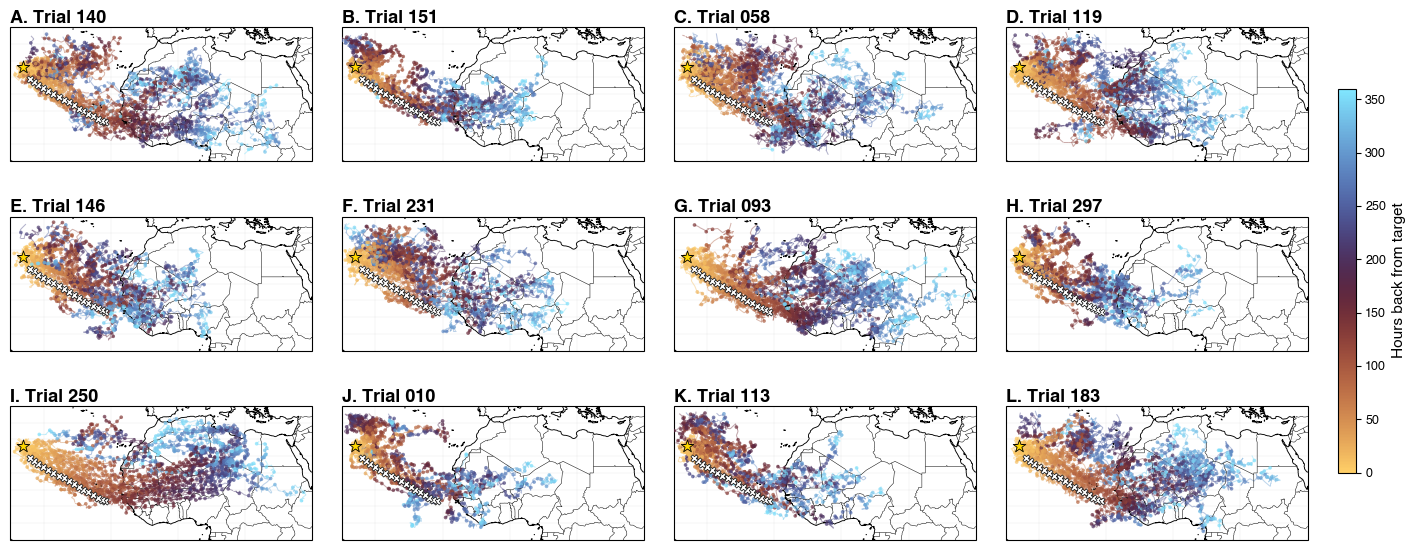

In [186]:
fig_supp_debby, axes_supp_debby, selected_debby_trials = plot_random_trial_ensemble_gallery_fig3(
    trial_ids=debby_trial_ids,
    jobs_df_case=jobs_df_debby,
    full_data_run=full_data_debby,
    n_runs=12,
    seed=42,
    extent=extent_debby,
    event_lon=event_lon_debby,
    event_lat=event_lat_debby,
    observed_lon=storm_lon,
    observed_lat=storm_lat,
    observed_stride=2,
    cmap_name="managua",
    lag_vmax=360,
    cbar_label="Hours back from target",
    timeres=1.0,
    point_stride=6,
    figsize=(15, 6),
)

plt.show()

fig_supp_debby.savefig("sup_debby_random_ensembles.pdf", bbox_inches="tight")

Selected trials: [782, 645, 559, 514, 889, 234, 193, 308, 220, 546, 750, 229]


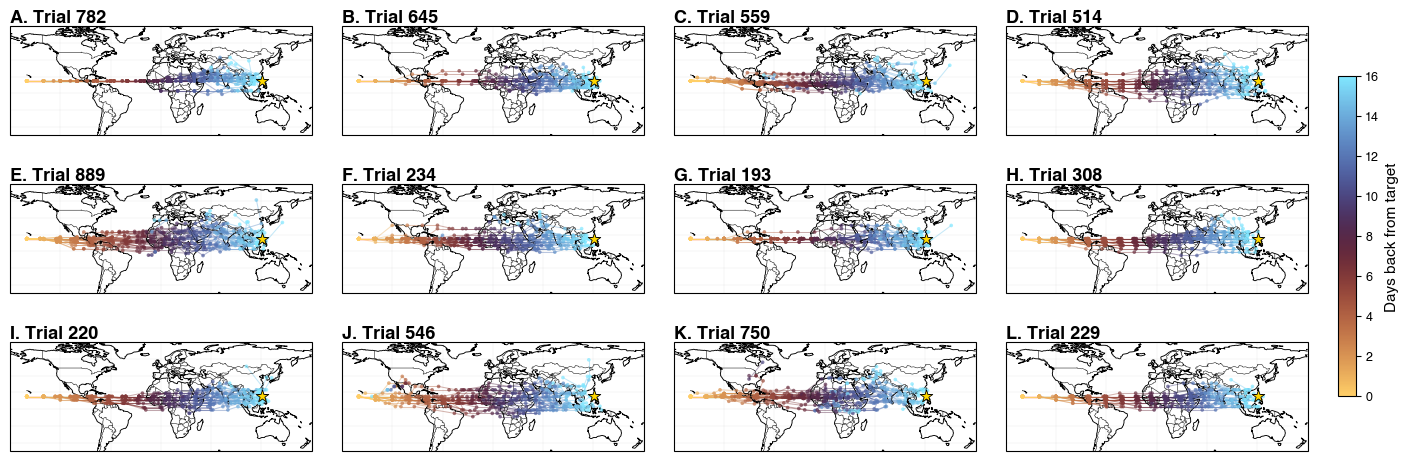

In [187]:
fig_supp_pinatubo, axes_supp_pinatubo, selected_pinatubo_trials = plot_random_trial_ensemble_gallery_fig3(
    trial_ids=pinatubo_trial_ids,
    jobs_df_case=jobs_df_pinatubo,
    full_data_run=full_data_pinatubo,
    n_runs=12,
    seed=42,
    extent=(-180, 180, -50, 80),
    event_lon=volcano_lon,
    event_lat=volcano_lat,
    observed_lon=None,
    observed_lat=None,
    cmap_name="managua",
    lag_vmax=16,
    cbar_label="Days back from target",
    timeres=1.0,
    point_stride=1,
    figsize=(15, 5),
)

plt.show()

fig_supp_pinatubo.savefig("sup_pinatubo_random_ensembles.pdf", bbox_inches="tight")

In [200]:
# ============================================================
# Supplementary composites: mean standardized anomalies
# over the density/relevance time range
# ============================================================

def _get_density_range_steps(jobs_df_case, trial_ids=None):
    if trial_ids is not None:
        jobs_sel = jobs_df_case[jobs_df_case["trial_id"].isin(trial_ids)].copy()
    else:
        jobs_sel = jobs_df_case.copy()

    start_col = "density_range_start_step"
    end_col = "density_range_end_step_exclusive"

    if start_col in jobs_sel.columns and end_col in jobs_sel.columns:
        a = int(np.nanmedian(pd.to_numeric(jobs_sel[start_col], errors="coerce")))
        b = int(np.nanmedian(pd.to_numeric(jobs_sel[end_col], errors="coerce")))
        return a, b

    raise ValueError("Could not find density_range_start_step / density_range_end_step_exclusive.")


def _mean_composite_for_step_range(
    full_data_run,
    *,
    var_name,
    date_end,
    start_step,
    end_step,
    timeres="hours",  # "hours" or "days"
):
    fields = []
    date_end_ts = pd.Timestamp(date_end)

    for step in range(int(start_step), int(end_step)):
        if timeres == "hours":
            target_time = date_end_ts - pd.Timedelta(hours=int(step))
        elif timeres == "days":
            target_time = date_end_ts - pd.Timedelta(days=int(step))
        else:
            raise ValueError("timeres must be 'hours' or 'days'")

        da = full_data_run.sel(var=var_name).sel(time=target_time, method="nearest")
        fields.append(da)

    return xr.concat(fields, dim="composite_step").mean("composite_step")


def plot_case_mean_anomaly_composites(
    *,
    full_data_run,
    var_names,
    date_end,
    start_step,
    end_step,
    timeres="hours",
    extent=(-50, 40, 0, 40),
    event_lon=None,
    event_lat=None,
    observed_lon=None,
    observed_lat=None,
    observed_stride=2,
    cmap="RdBu_r",
    vmin=-2,
    vmax=2,
    figsize=(12, 3.1),
    cbar_label="Mean standardized anomaly",
    title_prefix="",
):
    geo = ccrs.PlateCarree()
    nvars = len(var_names)

    fig, axes = plt.subplots(
        1,
        nvars,
        figsize=figsize,
        subplot_kw=dict(projection=geo),
        squeeze=False,
    )
    axes = axes[0]

    mesh = None

    for i, (ax, var_name) in enumerate(zip(axes, var_names)):
        _fig3_style_geo_ax(ax, extent, add_grid=True)

        da = _mean_composite_for_step_range(
            full_data_run,
            var_name=var_name,
            date_end=date_end,
            start_step=start_step,
            end_step=end_step,
            timeres=timeres,
        )

        lon_name = "lon" if "lon" in da.coords else "longitude"
        lat_name = "lat" if "lat" in da.coords else "latitude"

        lonp = lon0360_to_m180_180(np.asarray(da[lon_name].values, dtype=float))
        order = np.argsort(lonp)
        latp = np.asarray(da[lat_name].values, dtype=float)
        vals = np.asarray(da.values, dtype=float)

        mesh = ax.pcolormesh(
            lonp[order],
            latp,
            vals[:, order],
            transform=geo,
            shading="auto",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            zorder=1,
            rasterized=True,
        )

        if observed_lon is not None and observed_lat is not None:
            idx = np.arange(len(observed_lon))[::observed_stride]
            ax.plot(
                np.asarray(observed_lon)[idx],
                np.asarray(observed_lat)[idx],
                "-",
                color="0.1",
                linewidth=1.0,
                alpha=0.9,
                transform=geo,
                zorder=6,
            )
            ax.scatter(
                np.asarray(observed_lon)[idx],
                np.asarray(observed_lat)[idx],
                s=11,
                color="0.1",
                marker="o",
                transform=geo,
                zorder=7,
            )

        if event_lon is not None and event_lat is not None:
            ax.scatter(
                event_lon,
                event_lat,
                marker="*",
                s=70,
                color="gold",
                edgecolor="k",
                linewidth=0.55,
                transform=geo,
                zorder=10,
            )

        label = FIG3_LABELS.get(var_name, var_name)
        ax.set_title(
            f"{chr(65+i)}. {label}",
            loc="left",
            fontsize=13,
            fontweight="bold",
            pad=4,
        )

    fig.subplots_adjust(
        left=0.035,
        right=0.965,
        top=0.90,
        bottom=0.22,
        wspace=0.12,
    )

    cax = fig.add_axes([0.35, 0.2, 0.30, 0.025])
    cb = fig.colorbar(mesh, cax=cax, orientation="horizontal")
    cb.set_label(cbar_label, fontsize=10.5, labelpad=2)
    cb.ax.tick_params(labelsize=9.5, pad=1)
    cb.outline.set_linewidth(0.6)

    if title_prefix:
        fig.suptitle(title_prefix, fontsize=14, fontweight="bold", y=0.985)

    return fig, axes

In [224]:
def _composite_for_step_range(
    full_data_run,
    *,
    var_name,
    date_end,
    start_step,
    end_step,
    timeres="hours",
    mode="mean",  # "mean" or "std"
):
    fields = []
    date_end_ts = pd.Timestamp(date_end)

    for step in range(int(start_step), int(end_step)):
        if timeres == "hours":
            target_time = date_end_ts - pd.Timedelta(hours=int(step))
        elif timeres == "days":
            target_time = date_end_ts - pd.Timedelta(days=int(step))
        else:
            raise ValueError("timeres must be 'hours' or 'days'")

        da = full_data_run.sel(var=var_name).sel(time=target_time, method="nearest")
        fields.append(da)

    da_all = xr.concat(fields, dim="composite_step")

    if mode == "mean":
        return da_all.mean("composite_step")
    elif mode == "std":
        return da_all.std("composite_step")
    else:
        raise ValueError("mode must be 'mean' or 'std'")


def plot_case_mean_std_anomaly_composites(
    *,
    full_data_run,
    var_names,
    date_end,
    start_step,
    end_step,
    timeres="hours",
    extent=(-50, 40, 0, 40),
    event_lon=None,
    event_lat=None,
    observed_lon=None,
    observed_lat=None,
    observed_stride=2,

    mean_cmap="RdBu_r",
    mean_vmin=-2,
    mean_vmax=2,

    std_cmap="YlGn",
    std_vmin=0,
    std_vmax=2,

    figsize=(12, 5.4),
    mean_cbar_label="Mean standardized anomaly",
    std_cbar_label="Standard deviation",
):
    geo = ccrs.PlateCarree()
    nvars = len(var_names)

    fig, axes = plt.subplots(
        2,
        nvars,
        figsize=figsize,
        subplot_kw=dict(projection=geo),
        squeeze=False,
    )

    mean_mesh = None
    std_mesh = None

    for j, var_name in enumerate(var_names):
        label = FIG3_LABELS.get(var_name, var_name)

        for irow, mode in enumerate(["mean", "std"]):
            ax = axes[irow, j]
            _fig3_style_geo_ax(ax, extent, add_grid=True)

            da = _composite_for_step_range(
                full_data_run,
                var_name=var_name,
                date_end=date_end,
                start_step=start_step,
                end_step=end_step,
                timeres=timeres,
                mode=mode,
            )

            lon_name = "lon" if "lon" in da.coords else "longitude"
            lat_name = "lat" if "lat" in da.coords else "latitude"

            lonp = lon0360_to_m180_180(np.asarray(da[lon_name].values, dtype=float))
            order = np.argsort(lonp)
            latp = np.asarray(da[lat_name].values, dtype=float)
            vals = np.asarray(da.values, dtype=float)

            if mode == "mean":
                mesh = ax.pcolormesh(
                    lonp[order],
                    latp,
                    vals[:, order],
                    transform=geo,
                    shading="gouraud",
                    cmap=mean_cmap,
                    vmin=mean_vmin,
                    vmax=mean_vmax,
                    zorder=1,
                    rasterized=True,
                )
                mean_mesh = mesh
                panel_letter = chr(65 + j)
                title_mode = "Mean"
            else:
                mesh = ax.pcolormesh(
                    lonp[order],
                    latp,
                    vals[:, order],
                    transform=geo,
                    shading="gouraud",
                    cmap=std_cmap,
                    vmin=std_vmin,
                    vmax=std_vmax,
                    zorder=1,
                    rasterized=True,
                )
                std_mesh = mesh
                panel_letter = chr(65 + nvars + j)
                title_mode = "Std."

            if observed_lon is not None and observed_lat is not None:
                idx = np.arange(len(observed_lon))[::observed_stride]
                ax.plot(
                    np.asarray(observed_lon)[idx],
                    np.asarray(observed_lat)[idx],
                    "-",
                    color="0.1",
                    linewidth=1.0,
                    alpha=0.9,
                    transform=geo,
                    zorder=6,
                )
                ax.scatter(
                    np.asarray(observed_lon)[idx],
                    np.asarray(observed_lat)[idx],
                    s=11,
                    color="0.1",
                    marker="o",
                    transform=geo,
                    zorder=7,
                )

            if event_lon is not None and event_lat is not None:
                ax.scatter(
                    event_lon,
                    event_lat,
                    marker="*",
                    s=70,
                    color="gold",
                    edgecolor="k",
                    linewidth=0.55,
                    transform=geo,
                    zorder=10,
                )

            ax.set_title(
                f"{panel_letter}. {label} ({title_mode})",
                loc="left",
                fontsize=13,
                fontweight="bold",
                pad=4,
            )

    fig.subplots_adjust(
        left=0.035,
        right=0.965,
        top=0.94,
        bottom=0.16,
        wspace=0.12,
        hspace=0.20,
    )

    # Bottom side-by-side colorbars
    cax_mean = fig.add_axes([0.15, 0.1, 0.3, 0.018])
    cb_mean = fig.colorbar(mean_mesh, cax=cax_mean, orientation="horizontal")
    cb_mean.set_label(mean_cbar_label, fontsize=10.5, labelpad=1)
    cb_mean.ax.tick_params(labelsize=9.5, pad=1)
    cb_mean.outline.set_linewidth(0.6)

    cax_std = fig.add_axes([0.55, 0.1, 0.3, 0.018])
    cb_std = fig.colorbar(std_mesh, cax=cax_std, orientation="horizontal")
    cb_std.set_label(std_cbar_label, fontsize=10.5, labelpad=1)
    cb_std.ax.tick_params(labelsize=9.5, pad=1)
    cb_std.outline.set_linewidth(0.6)

    return fig, axes

Debby composite range: 96 360 hours back


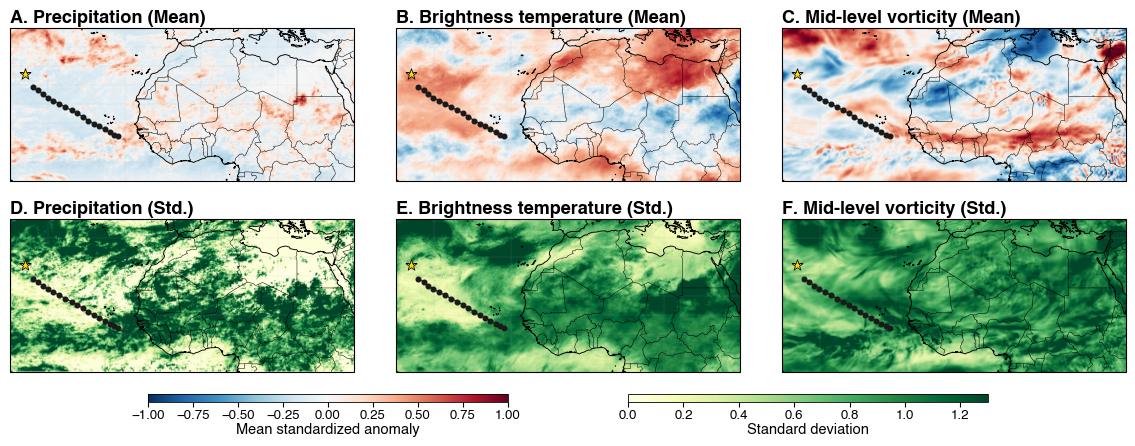

In [225]:
debby_a, debby_b = _get_density_range_steps(jobs_df_debby, debby_trial_ids)
print("Debby composite range:", debby_a, debby_b, "hours back")

fig_supp_debby_comp2, axes_supp_debby_comp2 = plot_case_mean_std_anomaly_composites(
    full_data_run=full_data_debby,
    var_names=["precip", "Tb", "vo"],
    date_end=date_end_debby,
    start_step=debby_a,
    end_step=debby_b,
    timeres="hours",
    extent=extent_debby,
    event_lon=event_lon_debby,
    event_lat=event_lat_debby,
    observed_lon=storm_lon,
    observed_lat=storm_lat,
    observed_stride=2,

    mean_cmap="RdBu_r",
    mean_vmin=-1,
    mean_vmax=1,

    std_cmap="YlGn",
    std_vmin=0,
    std_vmax=1.3,

    figsize=(12, 4.5),
)

plt.show()
fig_supp_debby_comp2.savefig("sup_debby_mean_anomaly_composites.pdf", bbox_inches="tight")

Pinatubo composite range: 4 16 days back


/glade/work/jhayron/conda-envs/castle/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


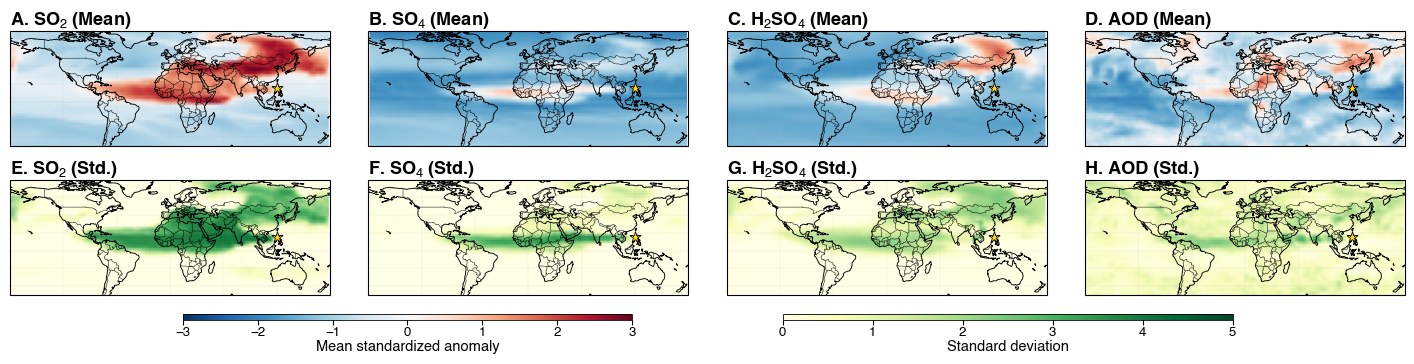

In [226]:
pin_a, pin_b = _get_density_range_steps(jobs_df_pinatubo, pinatubo_trial_ids)
print("Pinatubo composite range:", pin_a, pin_b, "days back")

fig_supp_pinatubo_comp2, axes_supp_pinatubo_comp2 = plot_case_mean_std_anomaly_composites(
    full_data_run=full_data_pinatubo,
    var_names=["TMSO201", "BURDENSO401", "TMH2SO401", "AEROD_v"],
    date_end=date_end_pinatubo,
    start_step=pin_a,
    end_step=pin_b,
    timeres="days",
    extent=(-180, 180, -50, 80),
    event_lon=volcano_lon,
    event_lat=volcano_lat,

    mean_cmap="RdBu_r",
    mean_vmin=-3,
    mean_vmax=3,

    std_cmap="YlGn",
    std_vmin=0,
    std_vmax=5,

    figsize=(15, 3.5),
)

plt.show()
fig_supp_pinatubo_comp2.savefig("sup_pinatubo_mean_anomaly_composites.pdf", bbox_inches="tight")